# Textual data scraping and preprocessing

> This course is a reworking of the excellent book designed by Melanie Walsh, [*Introduction to Cultural Analytics & Python*](https://melaniewalsh.github.io/Intro-Cultural-Analytics/welcome.html). Many paragraphs and explanations have been retained without modification.

> **Read this book!**, itself inspired by *Inspired by web scraping lessons from [Lauren Klein](https://github.com/laurenfklein/emory-qtm340/blob/master/notebooks/class4-web-scraping-complete.ipynb) and [Allison Parrish](https://github.com/aparrish/dmep-python-intro/blob/master/scraping-html.ipynb)*

Classically, a distinction is made between different work stages: (1) data production, (2) data processing and (3) data analysis.
This course is a practical and fairly detailed introduction to the first 2 stages: **production and (pre)processing**.

You'll learn how to use open Web services to automatically collect textual data. In doing so, you'll gain a better understanding of how the Web works (HTTP, HTML), discover structured data formats (CSV, JSON, XML) and get hands-on experience of the Python programming language.

The important thing is not necessarily to retain everything, but to gain a better understanding of how this ecosystem works, so that you can gradually determine by yourself the solutions you need to implement to meet your own requirements.


In this lesson, we're going to introduce :

1. how to "scrape" data from the internet with the Python libraries requests and BeautifulSoup.
1. how to preprocess our datas with spaCy.

We will cover how to:

* Programmatically access the text of a web page
* Extract informations from structured documents (CSV/TSV, HTML, JSON, XML)
* Build collections of texts
* Design pre-processings

And along the way, we'll be learning the basics of the Python programming language.

## Why Do We Need To Scrape At All?

Today, written heritage is massively available on the Internet under Free Licenses.

Community initiatives such as Project Gutenberg, based on crowdsourcing, have been succeeded by very large-scale institutional projects exploiting the potential of machine learning for the automatic acquisition of text, including handwritten. Gallica (BnF's digital library) represents over 10 million documents available online.

Here are a few projects worth your attention :

- [Project Gutenberg](https://www.gutenberg.org/): since December 1971! Project Gutenberg is a library of free electronic versions of physically existing books (>70,000 free eBooks).
- [Wikisource](https://fr.wikisource.org/wiki/Wikisource:Accueil): Wikisource is a digital library of public domain texts, managed as a wiki using the MediaWiki engine (> 360,000 free and open texts).
- [Gallica](https://gallica.bnf.fr/): Gallica is the digital library of the Bibliothèque nationale de France and its partners. It has been freely accessible since 1997, and contains > 10 million documents.
- [HathiTrust](https://www.hathitrust.org/)
- …

This digital heritage opens up unprecedented prospects for the humanities: provided, of course, that we know how to use these services in order to build research corpora. Text is also increasingly natively digital, and researchers often need to automatically follow certain subjects on platforms such as Twitter.

This course will not teach you how to analyze these huge textual corpora, but rather how to build them. It will also show you how to pre-process them, an essential prerequisite for computational analysis.

**Building the collection of Jules Verne novels**

Let's start by building up a small corpus of Jules Verne's works available on Project Gutenberg. In the process, we'll discover HTTP.

## Reading a metadata table using Pandas (CSV/TSV)

![csv](../img/verne_csv.png)

A [comma-separated values](https://en.wikipedia.org/wiki/Comma-separated_values) (CSV) file is a delimited text file that uses a comma to separate values. Each line of the file is a data record. Each record consists of one or more fields, separated by commas. The use of the comma as a field separator is the source of the name for this file format. A CSV file typically stores tabular data (numbers and text) in plain text, in which case each line will have the same number of fields.

The T of TSV is for 'tabulation'. Tabs are more convenient for separating text values, which may themselves contain commas...
In short, our lesson begins with the reading of a simple TSV metadata table, which is a very common data exchange format.

=====

**[Pandas](https://pandas.pydata.org/)** is a library written for the Python programming language, enabling data manipulation and analysis. In particular, it offers data structures and array manipulation operations.

Here, we use Pandas to read a [TSV table](https://en.wikipedia.org/wiki/Comma-separated_values) and store its data in a [DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) (a 2-dimensional array), so that it can be manipulated.

In [1]:
import pandas as pd

In [2]:
urls = pd.read_csv("../data/verne.csv", delimiter='\t', encoding='utf-8')
# Get an overview
urls.head()

,Etext-No.,Author,Title,url,Language
0,26823,"Verne, Jules, 1828-1905",Michel Strogoff: Pièce à grand spectacle en 5 ...,https://www.gutenberg.org/cache/epub/26823/pg2...,fr
1,800,"Verne, Jules, 1828-1905",Le tour du monde en quatre-vingts jours,https://www.gutenberg.org/cache/epub/800/pg800...,fr
2,3456,"Verne, Jules, 1828-1905",Le tour du monde en quatre-vingts jours,https://www.gutenberg.org/cache/epub/3456/pg34...,fr
3,4548,"Verne, Jules, 1828-1905",Cinq Semaines En Ballon,https://www.gutenberg.org/cache/epub/4548/pg45...,fr
4,4717,"Verne, Jules, 1828-1905",Autour de la Lune,https://www.gutenberg.org/cache/epub/4717/pg47...,fr


Here, the list of books and their metadata (download link, language) has been compiled in advance. We'll see later how to collect this information automatically, using a search API such as that provided by BnF.

Let's learn how to read the DataFrame in different ways and to access the values contained in the cells.

In [3]:
# Knowing the size of the df
print(
    f"{'Dimensions':15}"
    f"{'Lines':15}"
    f"{'Columns'}"
)
print(
    f"{str(urls.shape):15}"
    f"{str(urls.shape[0]):15}"
    f"{str(urls.shape[1])}"
)

Dimensions     Lines          Columns
(46, 5)        46             5


You can access one or more specific lines or slices using the [`.iloc[]`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html) property.

In [4]:
# Access a specific line
urls.iloc[5]

Etext-No.                                                 4791
Author                                 Verne, Jules, 1828-1905
Title                             Voyage au Centre de la Terre
url          https://www.gutenberg.org/cache/epub/4791/pg47...
Language                                                    fr
Name: 5, dtype: object

In [5]:
# Access specific lines
urls.iloc[[5, 7, 11]]

,Etext-No.,Author,Title,url,Language
5,4791,"Verne, Jules, 1828-1905",Voyage au Centre de la Terre,https://www.gutenberg.org/cache/epub/4791/pg47...,fr
7,5081,"Verne, Jules, 1828-1905",Les Indes Noires,https://www.gutenberg.org/cache/epub/5081/pg50...,fr
11,5097,"Verne, Jules, 1828-1905",Vingt mille Lieues Sous Les Mers — Complete,https://www.gutenberg.org/cache/epub/5097/pg50...,fr


In [6]:
# Access a slice of lines
urls.iloc[5:8]

,Etext-No.,Author,Title,url,Language
5,4791,"Verne, Jules, 1828-1905",Voyage au Centre de la Terre,https://www.gutenberg.org/cache/epub/4791/pg47...,fr
6,4968,"Verne, Jules, 1828-1905",Les Cinq Cents Millions De La Bégum,https://www.gutenberg.org/cache/epub/4968/pg49...,fr
7,5081,"Verne, Jules, 1828-1905",Les Indes Noires,https://www.gutenberg.org/cache/epub/5081/pg50...,fr


You can get cell value by index or name.

In [7]:
row = urls.iloc[5]
print(
    str(row.iloc[2]),
    "<=>",
    str(row["Title"]),
)

Voyage au Centre de la Terre <=> Voyage au Centre de la Terre


Each novel title in this TSV file is paired with a URL for the plain text. How can we actually use these URLs to get computationally tractable text data? Though we could manually navigate to each URL and copy/paste each screenplay into a file, that would be suuuuper slow and painstaking. It would be much better to programmatically access the text data attached to every URL.

## HTTP Requests and Responses

To programmatically access the text data attached to every URL, we can use a Python libraries called [requests](https://docs.python-requests.org/en/master/index.html?__cf_chl_tk=u5j0X_upTxzWZ63ZrOYzCIskE1Nwjj8Wn5FiY.3yKjM-1782398939-1.0.1.1-2qSZzNQBwYxp8IodMWkS7bFmjALMg.7uNmEQ1VtH8cs) or [httpx](https://www.python-httpx.org/). httpx is a modern HTTP client for Python that provides a familiar, requests-compatible API while also supporting **async/await** — which will be useful when we need to fetch many URLs concurrently.

A [Uniform Resource Locator](https://en.wikipedia.org/wiki/URL) (URL, ~ a web address), is a reference to a web resource that specifies its location on a computer network and a mechanism for retrieving it.

Every HTTP URL conforms to the syntax of a generic URI. The URI generic syntax consists of 6 components organized hierarchically:

`http://www.domain.com:80/path/to/myfile.html?key1=value1&key2=value2#anchor_in_doc`

URLS parts:

- **protocol**: `http://` or `https://`.
- **domain name**: `www.domain.com` –instead of a domain name, you can use an IP address.
- **port**: `:80` –indicates the technical "door" to be used to access the server's resources. This fragment is generally absent, as the browser uses the standard ports associated with the protocols (80 for HTTP, 443 for HTTPS).
- **path**: `/path/to/myfile.html` –path, on the web server, to the resource. In the early days of the Web, this path often corresponded to a "physical" path existing on the server. Today, this path is merely an abstraction managed by the web server, and no longer corresponds to a "physical" reality.
- **parameters**: `?key1=value1&key2=value2` –constructed as a list of key/value pairs separated by an ampersand.
- **anchor**: `#anchor_in_doc` –points to a given location in the resource.

When you type in a URL in your search address bar, you're sending an HTTP **request** for a web page, and the server which stores that web page will accordingly send back a **response**, some web page data that your browser will render.

<img src="../img/http.png" width="600px">

In the image below, in the inspector's network tab, you can see that for the URL, 2 HTTP requests received a positive response (status 200).

![404](../img/request-response.png)

### Get HTML Data with httpx

**HTTP**

In the HTTP protocol, a **method** is a command specifying a type of request, i.e. asking the server to perform an action. In general, the action concerns a resource identified by the URL following the method name.

There are many [methods](https://en.wikipedia.org/wiki/HTTP#HTTP/1.1_request_messages), the most common being `GET`, `HEAD` and `POST` :

- `GET`: the most common method for requesting a resource. A GET request has no effect on the resource.
- `HEAD`: this method only requests information about the resource, without actually requesting the resource itself.
- `POST`: this method is used to send data for processing (usually from an HTML form).

**Requests Python Library**

With the [`.get()` method](https://requests.readthedocs.io/en/latest/api/#requests.get), we can request to "get" web page data for a specific URL, which we will store in a varaible called `response`.

In [8]:
import httpx

> **`requests` vs `httpx` — at a glance**
>
> The two libraries share a near-identical synchronous API, so switching is straightforward:
>
> ```python
> # requests (classic)
> import requests
> response = requests.get("https://example.com", timeout=10)
> response.raise_for_status()
> print(response.status_code)   # 200
> print(response.text)          # HTML string
> print(response.json())        # parsed JSON
>
> # httpx (drop-in replacement + async support)
> import httpx
> response = httpx.get("https://example.com", timeout=10)
> response.raise_for_status()
> print(response.status_code)   # 200
> print(response.text)          # HTML string
> print(response.json())        # parsed JSON
> ```
>
> The key advantage of httpx: it also provides `httpx.AsyncClient` for use with `async/await`, which we will use later to fetch multiple URLs concurrently.

In [9]:
response = httpx.get("https://www.gutenberg.org/cache/epub/4791/pg4791.txt", timeout=30, follow_redirects=True)
response.raise_for_status()

<Response [200 OK]>

### HTTP Header Fields

Wikipedia: "[HTTP header fields](https://en.wikipedia.org/wiki/List_of_HTTP_header_fields) are a **list of strings sent and received by both the client program and server on every HTTP request and response. These headers are usually invisible to the end-user and are only processed or logged by the server and client applications. They define how information sent/received through the connection are encoded** (as in Content-Encoding), the session verification and identification of the client (as in browser cookies, IP address, user-agent) or their anonymity thereof (VPN or proxy masking, user-agent spoofing), how the server should handle data (as in Do-Not-Track), the age (the time it has resided in a shared cache) of the document being downloaded, amongst others."


In [10]:
response.headers

Headers({'date': 'Tue, 07 Jul 2026 09:11:28 GMT', 'server': 'Apache', 'last-modified': 'Thu, 02 Jul 2026 16:00:48 GMT', 'accept-ranges': 'bytes', 'content-length': '461113', 'x-backend': 'gutenweb7', 'content-type': 'text/plain; charset=utf-8'})

Thus, using the `headers` [`Response` object](https://www.python-httpx.org/api/#response); we can see that the document returned by Project Gutenberg is a plain text file.

But more often than not, as we'll soon see, responses are encoded in HTML.

In [11]:
response.headers['Content-Type']

'text/plain; charset=utf-8'

### HTTP Status Code

If we check out `response`, it will simply tell us its [HTTP response code](https://developer.mozilla.org/en-US/docs/Web/HTTP/Status), aka whether the request was successful or not.

"200" is a successful response, while "404" is a common "Page Not Found" error.

In [12]:
response

<Response [200 OK]>

Let's see what happens if we make a mistake entering the URL...  
('page4791' instead of 'pg4791')

In [13]:
bad_response = httpx.get("https://www.gutenberg.org/cache/epub/4791/page4791.txt", timeout=30, follow_redirects=True)
bad_response

<Response [404 Not Found]>

![404](../img/bad_response.png)

### Extract Text From Web Page

To actually get at the text data in the reponse, we need to use [`.text` property](https://www.python-httpx.org/api/#httpx.Response.text), which we will save in a variable called `text_string`.

Project Gutenberg provides here a version of the novel in plain text format (what is very convenient from a pedagogical point of view). But more often, the text data that we're getting on the Web is formatted in the HTML markup language, which we will talk more about in the BeautifulSoup section below.

In [14]:
# Store the first 2000 characters of the text in a variable to print
text_string = response.text[:2000]

Here's the text of the novel now in a variable.

In [15]:
print(text_string)

The Project Gutenberg eBook of Voyage au Centre de la Terre
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Voyage au Centre de la Terre

Author: Jules Verne


        
Release date: December 1, 2003 [eBook #4791]
                Most recently updated: May 12, 2023

Language: French

Other information and formats: www.gutenberg.org/ebooks/4791

Credits: Carlo Traverso, Robert Rowe, Charles Franks
        and the Online Distributed Proofreading Team.
        Revised by Richard Tonsing.


*** START OF THE PROJECT GUTENBERG EBOOK VOYAGE AU CENTRE DE LA TERRE ***




We thank the Bibliothe

### Extract Text From Multiple Web Pages

Repeating the operation for each novel would be tedious… Let's see how we can extract the text for every URL in the DataFrame at once. To do so, we're going to create a smaller DataFrame containing the first 10 novels — fewer processings for the demonstration and the planet…

**Why not just loop sequentially?**

The naive approach — iterating over URLs one by one with `httpx.get()` — works, but it is slow. Each HTTP request is an **I/O-bound** operation: the program sends a request, then *waits* (doing nothing) until the server responds. On a list of dozens or hundreds of URLs, that idle waiting time accumulates.

**The solution: asynchronous I/O with `asyncio`**

Instead of blocking while waiting for each response, Python's `asyncio` model allows a coroutine to *suspend itself* (`await`) the moment it is waiting for the network, immediately yielding control back to the **event loop**, which can then start — or resume — another coroutine. The CPU is never sitting idle; it switches between pending requests as their responses arrive.

We use [`httpx.AsyncClient`](https://www.python-httpx.org/async/) to send HTTP requests asynchronously, combined with `asyncio.Semaphore` to cap the number of requests in-flight at any given time (`max_concurrent=5`). This avoids overwhelming the target server while still gaining a large speed-up over sequential execution.

#### Let's look at some URLs :

In [16]:
sample_urls = urls[:10]

We define three functions:

- `scrape_novel(url)` — the **sequential** reference: one blocking `httpx.get()` call, no retry. Useful for comparison or single-URL use.
- `scrape_novel_async(client, url)` — the **async** version: uses `await` to suspend while waiting for the network, so the event loop can run other coroutines in parallel. Adds **exponential backoff with retry** (explained below).
- `scrape_all_async(urls)` — the **orchestrator**: opens a shared `httpx.AsyncClient` (one TCP connection pool for all requests), wraps each URL in a semaphore-gated coroutine, then runs everything concurrently with `asyncio.gather`.

In [17]:
import asyncio
import random
import httpx
from tqdm.asyncio import tqdm as tqdm_async


def scrape_novel(url: str) -> str:
    """Sequential version: one blocking request, no retry.
    
    Parameters
    ----------
    client : httpx.AsyncClient
        Shared async HTTP client (connection pool reused across calls).

    Returns
    -------
    str | None
        HTML content on success, None on final failure.
    """
    response = httpx.get(url, timeout=20, follow_redirects=True)
    response.raise_for_status()
    return response.text


# HTTP status codes for which the request should be retried.
RETRY_STATUS_CODES = {403, 429, 443, 500, 502, 503, 504}


async def scrape_novel_async(
    client: httpx.AsyncClient,
    url: str,
    max_retries: int = 5,
    backoff_factor: float = 1.0,
) -> str | None:
    """
    Async version: fetch one URL with exponential backoff and retry.

    Parameters
    ----------
    client : httpx.AsyncClient
        Shared async HTTP client (connection pool reused across calls).
    url : str
        URL of the resource to download.
    max_retries : int
        Maximum number of retries after the first attempt.
    backoff_factor : float
        Base number of seconds used to compute the retry delay.

    Returns
    -------
    str | None
        HTML content on success, None on final failure.
    """
    for attempt in range(max_retries + 1):
        try:
            response = await client.get(url, timeout=20, follow_redirects=True)
            if response.status_code not in RETRY_STATUS_CODES:
                response.raise_for_status()
                return response.text
            if attempt == max_retries:
                response.raise_for_status()
            retry_after = response.headers.get("Retry-After")
            if retry_after and retry_after.isdigit():
                delay = float(retry_after)
            else:
                # Exponential backoff: 1 s, 2 s, 4 s, 8 s, 16 s …
                delay = backoff_factor * (2 ** attempt)
                # Jitter: spread concurrent retries so they don't all fire at once.
                delay += random.uniform(0, 0.5 * delay)
            print(
                f"HTTP {response.status_code} for {url} — "
                f"retrying in {delay:.1f}s ({attempt + 1}/{max_retries})"
            )
            # Suspend only this coroutine; the event loop keeps running others.
            await asyncio.sleep(delay)
        except (httpx.TimeoutException, httpx.ConnectError) as error:
            if attempt == max_retries:
                print(f"Final network failure for {url}: {error}")
                return None
            delay = backoff_factor * (2 ** attempt)
            delay += random.uniform(0, 0.5 * delay)
            print(f"Network error for {url}: {error} — retrying in {delay:.1f}s")
            await asyncio.sleep(delay)
        except httpx.HTTPStatusError as error:
            print(f"Non-retryable error for {url}: {error}")
            return None
    return None


async def scrape_all_async(
    urls: list[str],
    max_concurrent: int = 5,
) -> list[str | None]:
    """
    Download all URLs concurrently, capped at max_concurrent in-flight requests.

    Uses asyncio.Semaphore to limit concurrency and tqdm_async.gather for
    a live progress bar without blocking the event loop.
    """
    semaphore = asyncio.Semaphore(max_concurrent)

    async def bounded(url: str) -> str | None:
        # The semaphore ensures at most max_concurrent coroutines run at once.
        async with semaphore:
            return await scrape_novel_async(client, url)

    async with httpx.AsyncClient(
        headers={
            "User-Agent": (
                "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/125.0 Safari/537.36"
            )
        }
    ) as client:
        # tqdm_async.gather wraps asyncio.gather with a live progress bar.
        return list(await tqdm_async.gather(
            *[bounded(url) for url in urls],
            desc="Scraping resources",
        ))


**Exponential backoff and retry**

When you send many requests in rapid succession, servers may start refusing them — typically with:

- `429 Too Many Requests` — rate limit exceeded
- `503 Service Unavailable` — server temporarily overloaded
- `502 Bad Gateway` / `504 Gateway Timeout` — infrastructure under pressure

Rather than failing immediately, `scrape_novel_async` catches these status codes and **waits before retrying**. The waiting time grows *exponentially* with each failed attempt:

| Attempt | Delay (with `backoff_factor=1`) |
|---------|----------------------------------|
| 1st retry | ~1 s |
| 2nd retry | ~2 s |
| 3rd retry | ~4 s |
| 4th retry | ~8 s |
| 5th retry | ~16 s |

This is **exponential backoff**: `delay = backoff_factor × 2^attempt`.

A **random jitter** (`± 50 %` of the delay) is added on top. Without it, all coroutines would wake up and retry at the *exact same moment* — recreating the spike that caused the rate-limit in the first place.

> **`await asyncio.sleep(delay)` vs `time.sleep(delay)`**  
> `time.sleep()` *blocks the entire thread*, freezing every other coroutine.  
> `await asyncio.sleep()` *suspends only the current coroutine*, returning control to the event loop so the other in-flight requests can continue.

If the server provides a [`Retry-After`](https://developer.mozilla.org/en-US/docs/Web/HTTP/Headers/Retry-After) header, we respect it directly instead of computing our own delay.

**Timeout**

When you call `httpx.get()`, your script **waits** for the server to reply. If the server is slow, overloaded, or unreachable, your script can hang indefinitely.

A **timeout** tells `httpx` how long to wait (in seconds) before giving up and raising a `Timeout` exception.`httpx` exposes a dedicated `Timeout` object that covers four distinct phases:

- **connect** : establishing the TCP connection.
- **read** : waiting for the server to send data.
- **write** : sending the request body (relevant for POST requests).
- **pool** : waiting to acquire a connection from the connection pool.

You can pass a single number (same limit for all phases) or build a `Timeout` object to set them individually.

In [18]:
# A single number applies to all phases
response = httpx.get(
    "https://www.gutenberg.org/cache/epub/4791/pg4791.txt",
    timeout=10
)

# Different numbers for each phase : control with a timeout object
timeout = httpx.Timeout(connect=5, read=10, write=5, pool=5)
response = httpx.get(
    "https://www.gutenberg.org/cache/epub/4791/pg4791.txt",
    timeout=timeout
)
response

<Response [200 OK]>

Then we're going to apply it to the "url" column of the DataFrame and create a new "text" column for the resulting extracted text.

In [19]:
# Sequential version – uncomment to compare performance:
# sample_urls['text'] = sample_urls['url'].apply(scrape_novel)

# Async version (default):
# Create an explicit copy to avoid SettingWithCopyWarning.
sample_urls = sample_urls.copy()
url_list = sample_urls["url"].tolist()

# In Jupyter, top-level await is supported natively by the running event loop.
# In a plain Python script, use instead: asyncio.run(scrape_all_async(url_list))
downloaded_texts = await scrape_all_async(url_list)

sample_urls.loc[:, "text"] = downloaded_texts

success_mask = sample_urls["text"].notna()
successful_count = int(success_mask.sum())
failed_count = int((~success_mask).sum())
total_count = len(sample_urls)

print("\nScraping completed")
print(f"Successful resources: {successful_count}/{total_count}")
print(f"Failed resources:     {failed_count}/{total_count}")
print(f"Success rate:         {successful_count / total_count:.1%}")


Scraping resources: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  6.72it/s]


Scraping completed
Successful resources: 10/10
Failed resources:     0/10
Success rate:         100.0%


In [20]:
sample_urls.head(3)

,Etext-No.,Author,Title,url,Language,text
0,26823,"Verne, Jules, 1828-1905",Michel Strogoff: Pièce à grand spectacle en 5 ...,https://www.gutenberg.org/cache/epub/26823/pg2...,fr,The Project Gutenberg eBook of Michel Strogoff...
1,800,"Verne, Jules, 1828-1905",Le tour du monde en quatre-vingts jours,https://www.gutenberg.org/cache/epub/800/pg800...,fr,The Project Gutenberg eBook of Le tour du mond...
2,3456,"Verne, Jules, 1828-1905",Le tour du monde en quatre-vingts jours,https://www.gutenberg.org/cache/epub/3456/pg34...,fr,The Project Gutenberg eBook of Le tour du mond...


The DataFrame above is truncated, so we can't see the full contents of the "text" column. But if we print out every row in the column, we can see that we successfully extracted text for each URL (though some of these URLs returned 404 errors).

In [131]:
print(sample_urls.iloc[4]['text'][:2000])

The Project Gutenberg eBook of Autour de la Lune
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Autour de la Lune

Author: Jules Verne


        
Release date: December 1, 2003 [eBook #4717]
                Most recently updated: May 30, 2011

Language: French

Other information and formats: www.gutenberg.org/ebooks/4717

Credits: Produced by John Walker, http://www.fourmilab.ch/
        HTML version by Chuck Greif


*** START OF THE PROJECT GUTENBERG EBOOK AUTOUR DE LA LUNE ***




Produced by John Walker, http://www.fourmilab.ch/








---------------------------------------------

It's simple and easy! However, that plain text format poses a few problems. It is not possible to automatically distinguish the Jules Verne text from the metadata and editorial paratext. Likewise, all the credit references at the end of the transcription are mixed in with the text, which can skew the analysis.

We need a more structured format that allows us to distinguish between the author's text, the metadata and the editorial paratext.

## Web Scraping

Not all web pages will be as easy to scrape as these Gutenberg project plain text files, however. Let's say we wanted to scrape the lyrics for NTM's song "[On est encore là](https://genius.com/Supreme-ntm-on-est-encore-la-lyrics)" (1998) from Genius.com.

NB. The teaching sequence is by Mélanie Walsh, and has been updated as the data model has evolved...

<img src="../img/ntm.png" class="center" >

Even at a glance, we can tell that this *Genius* web page is a lot more complicated than the *Gutengerg project* page and that it contains a lot of information beyond the lyrics.

Sure enough, if we use httpx again and try to grab the data for this web page, the underlying data is much more complicated, too.

In [22]:
response = httpx.get("https://genius.com/Supreme-ntm-on-est-encore-la-lyrics", timeout=30, follow_redirects=True)
html_string = response.text
print(html_string)

<!doctype html>
<html>
  <head>
    <meta itemprop="cf-country" content="FR">
    <meta itemprop="long-tail-cache" content="XX">
    <meta itemprop="cf-cache-status" content="MISS">
    <meta itemprop="rendered-with-cache" content="false">
    <meta itemprop="cf-latitude" content="48.85341">
    <meta itemprop="cf-longitude" content="2.3488">

    <title>Suprême NTM – On est encore là Lyrics | Genius Lyrics</title>

<meta http-equiv="Content-Type" content="text/html; charset=utf-8" />
<meta content='width=device-width,initial-scale=1' name='viewport'>
  <meta name="apple-itunes-app" content="app-id=709482991">
<link href="https://assets.genius.com/images/apple-touch-icon.png?1783366135" rel="apple-touch-icon" />


  <link href="https://assets.genius.com/images/apple-touch-icon.png?1783366135" rel="apple-touch-icon" />


  <!-- Mobile IE allows us to activate ClearType technology for smoothing fonts for easy reading -->
  <meta http-equiv="cleartype" content="on">



<META name="y_key" 

How can we extract just the song lyrics from this messy soup of a document? Luckily there's a Python library that can help us called [BeautifulSoup](https://beautiful-soup-4.readthedocs.io/en/latest/), which parses HTML documents.

To understand BeautifulSoup and HTML, we're going to take things one step at a time. We'll start with a very simple example (beginner level) to understand the basic structure of an HTML page. Next, we'll go back to the Jules Verne novels available on Project Gutenberg (intermediate level) before trying to automatically extract the lyrics to the NTM song (advanced level).

### HTML5

This [Singers' singers webpage](todolink) is adapted from Parrish's website titled "[Kittens and the TV Shows They Love](http://static.decontextualize.com/kittens.html)" made for the purposes of teaching BeautifulSoup.

Instant geek: thanks to IPython's [core.display module](https://ipython.org/ipython-doc/2/api/generated/IPython.core.display.html), it's even possible to display the content of a web page in a notebook.

In [23]:
from IPython.display import display, HTML
response = httpx.get("https://raw.githubusercontent.com/architexte/cours-data-processing/main/data/punk.html", timeout=30, follow_redirects=True)
html_string = response.text
display(HTML(html_string))

Let's take a look at the structure of this HTML page:

In [24]:
print(html_string)

<!doctype html>
<html>
  <head>
    <title>Singers' singers</title>
  </head>
  <body>
    <h1>Singers' singers</h1>
    <p class="subtitle">Singers and the Singers They Love</p>
    <div class="singer">
      <h2>Iggy Pop</h2>
      <div><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e8/Iggy_Pop_HS_Yearbook.jpeg/170px-Iggy_Pop_HS_Yearbook.jpeg"></div>
      <ul class="idols">
        <li><a href="https://en.wikipedia.org/wiki/Frank_Sinatra">Frank Sinatra</a></li>
        <li><a href="https://en.wikipedia.org/wiki/Jim_Morrison">Jim Morrison</a></li>
      </ul>
      Last check-up: <span class="lastcheckup">2023-05-30</span>
    </div>
    <div class="singer">
      <h2>Joe Strummer</h2>
      <div><img src="https://upload.wikimedia.org/wikipedia/commons/6/63/Joe_strummer_1999.jpg"></div>
      <ul class="idols">
        <li><a href="https://en.wikipedia.org/wiki/Johnny_Cash">Johnny Cash</a></li>
        <li><a href="https://en.wikipedia.org/wiki/John_Lydon">John Lydo

#### HTML Tags

HTML stands for HyperText Markup Language. It is the standard language for writing web page documents. The most important thing you need to know about HTML is that the language uses HTML "tags" to represent different elements, such as a main header `<h1>`. 

| HTML Tag                | Explanation                              |
|--------------------|-------------------------------------------|
| <\!DOCTYPE>        | Defines document type                 |
| <html\>             | Root of the HTML document                  |
| <head\>             | Metadata about document    |
| <title\>            | Title for document          |
| <body\>             | Document body               |
| <h1\> to <h6\>       |  Headings                    |
| <div\> | Bloc section in a document                   |
| <p\>                | Paragraph                       |
| <ul\> | Unordered list                     |
| <ol\> | Ordered list                     |
| <li\> | List item                     |
| <br\>               | Line break               |
| <a\> | Hyperlink                       |
| <img\> | Image                         |
| <span\> | Inline section in a document                   |
| <\!\-\-comment here-\-> | Comment                         |

HTML tags often, but not always, require a "closing" tag. For example, the main header "Kittens and the TV Shows They Love" will be surrounded by `<h1>` (opening tag) and `</h1>` (closing tag) on either side: `<h1>Singers' singers</h1>`

#### HTML Attributes, Classes, and IDs

HTML elements sometimes come with even more information inside a tag. This will often be a keyword (like `class` or `id`) followed by an equals sign `=` and a further descriptor such as `<div class="iggy">`.

We need to know about tags as well as attributes, classes, and IDs because this is how we're going to extract specific HTML data with BeautifulSoup.

### BeautifulSoup (Singers’ singers)

In [25]:
from bs4 import BeautifulSoup

To make a BeautifulSoup document, we call `BeautifulSoup()` with two parameters: the `html_string` from our HTTP request and [the kind of parser](https://www.crummy.com/software/BeautifulSoup/bs4/doc/#specifying-the-parser-to-use) that we want to use, which will always be `"html.parser"` for our purposes.

In [26]:
response = httpx.get("https://raw.githubusercontent.com/architexte/cours-data-processing/main/data/punk.html", timeout=30, follow_redirects=True)
html_string = response.text
document = BeautifulSoup(html_string, "html.parser")

In [27]:
print(type(document))

<class 'bs4.BeautifulSoup'>


In [28]:
document

<!DOCTYPE html>

<html>
<head>
<title>Singers' singers</title>
</head>
<body>
<h1>Singers' singers</h1>
<p class="subtitle">Singers and the Singers They Love</p>
<div class="singer">
<h2>Iggy Pop</h2>
<div><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e8/Iggy_Pop_HS_Yearbook.jpeg/170px-Iggy_Pop_HS_Yearbook.jpeg"/></div>
<ul class="idols">
<li><a href="https://en.wikipedia.org/wiki/Frank_Sinatra">Frank Sinatra</a></li>
<li><a href="https://en.wikipedia.org/wiki/Jim_Morrison">Jim Morrison</a></li>
</ul>
      Last check-up: <span class="lastcheckup">2023-05-30</span>
</div>
<div class="singer">
<h2>Joe Strummer</h2>
<div><img src="https://upload.wikimedia.org/wikipedia/commons/6/63/Joe_strummer_1999.jpg"/></div>
<ul class="idols">
<li><a href="https://en.wikipedia.org/wiki/Johnny_Cash">Johnny Cash</a></li>
<li><a href="https://en.wikipedia.org/wiki/John_Lydon">John Lydon</a></li>
</ul>
      Last check-up: <span class="lastcheckup">2023-06-01</span>
</div>
</body>
</ht

#### Extract HTML Element

We can use the [`.find()` method](https://www.crummy.com/software/BeautifulSoup/bs4/doc/#find) to find and extract certain elements, such as a main header.

In [29]:
document.find("h1")

<h1>Singers' singers</h1>

If we want only the text contained between those tags, we can use `.text` to extract just the text.

In [30]:
document.find("h1").text

"Singers' singers"

In [31]:
type(document.find("h1").text)

str

Find the HTML element that contains an image.

In [32]:
document.find("img")

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e8/Iggy_Pop_HS_Yearbook.jpeg/170px-Iggy_Pop_HS_Yearbook.jpeg"/>

In [33]:
document.find("img")['src']

'https://upload.wikimedia.org/wikipedia/commons/thumb/e/e8/Iggy_Pop_HS_Yearbook.jpeg/170px-Iggy_Pop_HS_Yearbook.jpeg'

**The `.find()` method returns only one result** (the first one).  
However, we may wish to obtain a list of all the images called up in the page.

#### Extract Multiple HTML Elements

You can also extract multiple HTML elements at a time with the [`.find_all()` method](https://www.crummy.com/software/BeautifulSoup/bs4/doc/#find-all) that returns a list.

In [34]:
document.find_all("img")

[<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e8/Iggy_Pop_HS_Yearbook.jpeg/170px-Iggy_Pop_HS_Yearbook.jpeg"/>,
 <img src="https://upload.wikimedia.org/wikipedia/commons/6/63/Joe_strummer_1999.jpg"/>]

With Python, it's easy to use a `for` loop to go through the list:

In [35]:
for img in document.find_all("img"):
    print(img['src'])

https://upload.wikimedia.org/wikipedia/commons/thumb/e/e8/Iggy_Pop_HS_Yearbook.jpeg/170px-Iggy_Pop_HS_Yearbook.jpeg
https://upload.wikimedia.org/wikipedia/commons/6/63/Joe_strummer_1999.jpg


It's possible to extract a serie of elements according to the value of their attributes (here, `div` whose class attribute value is `singer`).

In [36]:
document.find_all("div", attrs={"class": "singer"})

[<div class="singer">
 <h2>Iggy Pop</h2>
 <div><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e8/Iggy_Pop_HS_Yearbook.jpeg/170px-Iggy_Pop_HS_Yearbook.jpeg"/></div>
 <ul class="idols">
 <li><a href="https://en.wikipedia.org/wiki/Frank_Sinatra">Frank Sinatra</a></li>
 <li><a href="https://en.wikipedia.org/wiki/Jim_Morrison">Jim Morrison</a></li>
 </ul>
       Last check-up: <span class="lastcheckup">2023-05-30</span>
 </div>,
 <div class="singer">
 <h2>Joe Strummer</h2>
 <div><img src="https://upload.wikimedia.org/wikipedia/commons/6/63/Joe_strummer_1999.jpg"/></div>
 <ul class="idols">
 <li><a href="https://en.wikipedia.org/wiki/Johnny_Cash">Johnny Cash</a></li>
 <li><a href="https://en.wikipedia.org/wiki/John_Lydon">John Lydon</a></li>
 </ul>
       Last check-up: <span class="lastcheckup">2023-06-01</span>
 </div>]

In [37]:
document.find("h2").text

'Iggy Pop'

In [38]:
document.find_all("h2")

[<h2>Iggy Pop</h2>, <h2>Joe Strummer</h2>]

In [39]:
document

<!DOCTYPE html>

<html>
<head>
<title>Singers' singers</title>
</head>
<body>
<h1>Singers' singers</h1>
<p class="subtitle">Singers and the Singers They Love</p>
<div class="singer">
<h2>Iggy Pop</h2>
<div><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e8/Iggy_Pop_HS_Yearbook.jpeg/170px-Iggy_Pop_HS_Yearbook.jpeg"/></div>
<ul class="idols">
<li><a href="https://en.wikipedia.org/wiki/Frank_Sinatra">Frank Sinatra</a></li>
<li><a href="https://en.wikipedia.org/wiki/Jim_Morrison">Jim Morrison</a></li>
</ul>
      Last check-up: <span class="lastcheckup">2023-05-30</span>
</div>
<div class="singer">
<h2>Joe Strummer</h2>
<div><img src="https://upload.wikimedia.org/wikipedia/commons/6/63/Joe_strummer_1999.jpg"/></div>
<ul class="idols">
<li><a href="https://en.wikipedia.org/wiki/Johnny_Cash">Johnny Cash</a></li>
<li><a href="https://en.wikipedia.org/wiki/John_Lydon">John Lydon</a></li>
</ul>
      Last check-up: <span class="lastcheckup">2023-06-01</span>
</div>
</body>
</ht

``` {warning}
Heads up! The code below will cause an error.
```
Let's try to extract the text from all the header2 elements:

In [40]:
try:
    h2_elements = document.find_all("h2")
    h2_elements.text
except AttributeError as e:
    print(f"Error: {e}\n")
    print(f"'document.find_all('h2')' is type {type(document.find_all('h2'))}")

Error: ResultSet object has no attribute "text". You're probably treating a list of elements like a single element. Did you call find_all() when you meant to call find()?

'document.find_all('h2')' is type <class 'bs4.element.ResultSet'>


That didn't work! In order to extract text data from multiple HTML elements, we need a `for` loop and some list-building.

In [41]:
all_h2_headers = document.find_all("h2")
all_h2_headers

[<h2>Iggy Pop</h2>, <h2>Joe Strummer</h2>]

First we will make an empty list called `h2_headers`.

Then `for` each `header` in `all_h2_headers`, we will grab the `.text`, put it into a variable called `header_contents`, then `.append()` it to our `h2_headers` list.

In [42]:
h2_headers = []
for header in all_h2_headers:
    header_contents = header.text
    h2_headers.append(header_contents)

In [43]:
h2_headers

['Iggy Pop', 'Joe Strummer']

You can produce the same result in a more "pythonic" way by using a **list comprehension** (shorter syntax):

In [44]:
h2_headers = [header.text for header in all_h2_headers]
h2_headers

['Iggy Pop', 'Joe Strummer']

#### Inspect HTML Elements with Browser

Most times if you're looking to extract something from an HTML document, it's best to use your "Inspect" capabilities in your web browser. You can hover over elements that you're interested in and find that specific element in the HTML.

<img src="../img/inspect1.png" width="700px">

For example, if we hover over the main link "Johnny Cash":

<img src="../img/inspect2.png" width="700px" >

### Your Turn! (Project Gutenberg)

Ok so now we've learned a little bit about how to use BeautifulSoup to parse HTML documents. So how would we apply what we've learned to extract the text of Jules Verne's novels?

Project Gutenberg shares its editions in plain text format, but not only. An HTML version is of course also available. It's a little more difficult to process it than the full-text version, but at least we can try to extract metadata and the author's text alone.

Let's follow our example of the *Voyage au Centre de la Terre*: https://www.gutenberg.org/cache/epub/4791/pg4791.html.

Inspect the page with your browser and try to extract:

- the main header of the page
- the title of the novel
- `p` elements with `id``

Finally, try to extract the only text of the novel (the one written by Jules Verne).

In [45]:
response = httpx.get("https://www.gutenberg.org/cache/epub/4791/pg4791.html", timeout=30, follow_redirects=True)
response.raise_for_status()
html_string = response.text
document = BeautifulSoup(html_string, "html.parser")

In [46]:
# Main header
document.find('h2')

<h2 id="pg-header-heading" title="">The Project Gutenberg eBook of <span id="pg-title-no-subtitle" lang="fr">Voyage au Centre de la Terre</span></h2>

In [47]:
# Main header text
document.find('h2').text

'The Project Gutenberg eBook of Voyage au Centre de la Terre'

No `h1`elmement, it’s a semantic oddity... A closer look reveals that the hierarchy of headings is not even respected (`h5` > `h2`).

But note that thanks to BeautifulSoup, you can easily print the text contained in all descendant elements (here `span`). How convenient!

In [48]:
# Title of the novel
document.find("h5").text

'VOYAGE  AU  CENTRE DE  LA TERRE'

In [49]:
# First p element with an id attribute
document.find("p", {"id" : True})

<p id="id00000">We thank the Bibliotheque Nationale de France that has made available</p>

In [50]:
# The `p` element whose id value is 'id02329'.
document.find("p", {"id" : "id02329"})

<p id="id02329">—Explique-toi, mon garçon,</p>

In [51]:
# A `p` element that has an `id` attribute AND a `style` attribute.
document.find("p", attrs={"id" : True, "style" : True})

<p id="id00001" style="margin-top: 4em">the image files at www://gallica.bnf.fr, authorizing the preparation
of the etext through OCR.</p>

In [52]:
# Same, compact syntax
document.find("p", {"id" : True, "style" : True})

<p id="id00001" style="margin-top: 4em">the image files at www://gallica.bnf.fr, authorizing the preparation
of the etext through OCR.</p>

In [53]:
# List of the 10 first p elements with an id attribute
document.find_all("p", {"id" : True})[0:8]

[<p id="id00000">We thank the Bibliotheque Nationale de France that has made available</p>,
 <p id="id00001" style="margin-top: 4em">the image files at www://gallica.bnf.fr, authorizing the preparation
 of the etext through OCR.</p>,
 <p id="id00002" style="margin-top: 2em">Nous remercions la Bibliothèque Nationale de France qui a mis à
 disposition les images dans www://gallica.bnf.fr, et a donné
 l'authorisation à les utilizer pour préparer ce texte.</p>,
 <p id="id00003" style="margin-top: 4em">Editorial note: We emphasize with <i>X</i> the runes that Verne emphasizes
 with serifs, and translitterates with uppecase.</p>,
 <p id="id00004">Note de l'éditeur: On répresente avec <i>X</i> les runes que Verne relève
 avec des sérifs, et transcrit avec des maj uscules.</p>,
 <p id="id00005" style="margin-top: 4em">Jules Verne</p>,
 <p id="id00008" style="margin-top: 2em">Le 24 mai 1863, un dimanche, mon oncle, le professeur Lidenbrock,
 revint précipitamment vers sa petite maison située au

In [54]:
#document.find_all(['p', 'h2', 'h5'])
#document.find_all(['p', 'h2', 'h5'], id=True) # relou
#document.select('p[id], h2, h5')

Better, but we don't want to extract either the acknowledgements (`@id` 'id00000'-'id00002') or the editorial notes (`@id` 'id00003'-'id00005')...  
One strategy is to extract only the paragraphs following the novel's title (`h5`):

In [55]:
start_tag = document.find('h5')
start_tag.find_all_next('p')[0:2]

[<p id="id00008" style="margin-top: 2em">Le 24 mai 1863, un dimanche, mon oncle, le professeur Lidenbrock,
 revint précipitamment vers sa petite maison située au numéro 19
 de König-strasse, l'une des plus anciennes rues du vieux quartier
 de Hambourg.</p>,
 <p id="id00009">La bonne Marthe dut se croire fort en retard, car le dîner
 commençait à peine à chanter sur le fourneau de la cuisine.</p>]

We're making progress, but on closer inspection, we realize that we're forgetting the titles (`h2`). You can pass a list of elements to the `find_all_next()` method:

In [56]:
start_tag = document.find('h5')
start_tag.find_all_next(['p', 'h2'])[0:3]

[<h2 id="id00007" style="margin-top: 4em">I</h2>,
 <p id="id00008" style="margin-top: 2em">Le 24 mai 1863, un dimanche, mon oncle, le professeur Lidenbrock,
 revint précipitamment vers sa petite maison située au numéro 19
 de König-strasse, l'une des plus anciennes rues du vieux quartier
 de Hambourg.</p>,
 <p id="id00009">La bonne Marthe dut se croire fort en retard, car le dîner
 commençait à peine à chanter sur le fourneau de la cuisine.</p>]

All that's left is to save the text in a list, simply with a small loop:

In [57]:
verne_text_list = []
for element in start_tag.find_all_next(['p', 'h2']):
    text = element.text
    verne_text_list.append(text)
verne_text_list[0:3]

['I',
 "Le 24 mai 1863, un dimanche, mon oncle, le professeur Lidenbrock,\r\nrevint précipitamment vers sa petite maison située au numéro 19\r\nde König-strasse, l'une des plus anciennes rues du vieux quartier\r\nde Hambourg.",
 'La bonne Marthe dut se croire fort en retard, car le dîner\r\ncommençait à peine à chanter sur le fourneau de la cuisine.']

In [58]:
# Otherwise, print it all in a single string.
verne_p = document.find_all('p', id=True)
for element in start_tag.find_all_next(['p', 'h2'])[0:3]:
    print(element.text)

I
Le 24 mai 1863, un dimanche, mon oncle, le professeur Lidenbrock,
revint précipitamment vers sa petite maison située au numéro 19
de König-strasse, l'une des plus anciennes rues du vieux quartier
de Hambourg.
La bonne Marthe dut se croire fort en retard, car le dîner
commençait à peine à chanter sur le fourneau de la cuisine.


**Issue**

- find all `p` with id : `document.find_all('p', id=True)`

This syntax prohibits the selection of paragraphs with `id` and `h2` without: impossible to write `('[p', id=True, h2])`…  
In this case, you can use the `select()` method :

- select all `p` with id and all `h2` : ` document.select('p[id], h2')`

All you have to do is write:

```python
verne_text_list = [element.text for element in document.select('p[id], h2, h5')]
```

**Summary**

Thanks to HTML, BeautifulSoup and a little trickery, you can extract Jules Verne's text alone. A little more difficult than with the plain text format, but also more subtle: you manage to separate the author's text from the editorial paratext.

Issue: this recipe works for this novel, but what guarantee do we have that it will work for other texts? To automate extractions, we need standardized sources... That's one of the advantages of APIs.

### Your Turn! (Genius)

So how would we apply what we've learned to extract NTM lyrics?

https://genius.com/Supreme-ntm-on-est-encore-la-lyrics

What HTML element do we need to "find" to extract the song lyrics?

In [59]:
response = httpx.get("https://genius.com/Supreme-ntm-on-est-encore-la-lyrics", timeout=30, follow_redirects=True)
html_string = response.text
document = BeautifulSoup(html_string, "html.parser")

What do we have in the `p` elements?

In [60]:
ntm_p = document.find_all("p")
print(ntm_p)

[<p class="SongPage__HeaderSpace-sc-193a8f05-1 kYJlhT"></p>, <p class="LyricsEditExplainer__Title-sc-5ee744bd-1 hblbvQ">How to Format Lyrics:</p>, <p>To learn more about adding songs to Genius, check out the complete <a class="StyledLink-sc-9d0942b3-0 gKMaEh" font-weight="light" href="https://genius.com/Genius-how-to-add-songs-to-genius-annotated">transcription guide</a> or visit the <a class="StyledLink-sc-9d0942b3-0 gKMaEh" font-weight="light" href="https://genius.com/transcribers">transcribers forum</a></p>, <p>Artistes : KoolShen, Joeystarr<br/>
Instru :<br/>
(I) Madizm<br/>
(II) Zoxeakopat<br/>
Sample : Whayback – <a data-api_path="/songs/8394" href="https://genius.com/Artifacts-whayback-lyrics" rel="noopener">“Artifacts”</a><br/>
Album : <em>Suprême NTM</em> (1998)<br/>
[Bad image! Try pasting a different image link!]</p>, <p>Le double morceau de l'album éponyme du Suprême NTM, qui affirme la persévérance du duo dans sa subversion. La version (II) présente le même texte, privé de

What HTML element do we need to "find" to extract the title?

In [61]:
print(document.find('h1').text)

On est encore là


En inspectant la page, on s’aperçoit que certains éléments `div` ont un attribut `data-lyrics-container`

In [62]:
print(document.find('div', {"data-lyrics-container": "true"}).text)

18 ContributorsOn est encore là LyricsArtistes : KoolShen, Joeystarr… Read More [Couplet 1 - KoolShen]Retour en force de l'ordre moral, je veux surtout pas te casser ton moralMais c'est le bordel quand t'entres pas dans leur panel, je suis formelEt reste formé pour ça, nique le CSAC'est pour ça que j'ai gardé ma tenue de combatQue je lâcherai pas mon ton-bâ, fais gaffe à ton dos, protège tes abdosSi tu parles cash de leurs vices, ils te feront pas de cadeauOn nous censure parce que notre culture est trop basanéeQu'on représente pas assez la France du passéC'est carré, on veut nous stopper : ça allaitTant qu'on rappait dans les MJC, mais aujourd'huiLe phénomène a grandi, Dieu merci, je remercieLes jeunes qui rappent sans merci et puis nique sa mère, siOn passe pas dans leurs radios, on fera le tour, c'est pas graveLe plus dur c'était de sortir de la cave et les gens le saventHey, on est encore làPrêt à foutre le souk et tout le monde est ccord-d'a[Refrain - Joeystarr, KoolShen]Non, non 

**Issue**. We lose the lines of verse. What can we do? The [`get_text()` method](https://www.crummy.com/software/BeautifulSoup/bs4/doc/#get-text) returns all the text in a document (or beneath a tag) as a single Unicode string and enables to specify a string to be used to join the bits of text together…

In [63]:
lyrics = document.find('div', {"data-lyrics-container": "true"}).get_text("\n")
print(lyrics)

18 Contributors
On est encore là Lyrics
Artistes : KoolShen, Joeystarr… 
Read More
 
[Couplet 1 - KoolShen]
Retour en force de l'ordre moral
, je veux surtout pas te casser ton moral
Mais c'est le bordel quand t'entres pas dans leur panel
, je suis formel
Et reste formé pour ça, 
nique le CSA
C'est pour ça que j'ai gardé ma tenue de combat
Que je lâcherai pas mon ton-bâ, 
fais gaffe à ton dos, protège tes abdos
Si tu parles cash de leurs vices, ils te feront pas de cadeau
On nous censure parce que notre culture est trop basanée
Qu'on représente pas assez la France du passé
C'est carré, on veut nous stopper : ça allait
Tant qu'on rappait dans les MJC
, mais aujourd'hui
Le phénomène a grandi, Dieu merci, je remercie
Les jeunes qui rappent sans merci et puis
 
nique sa mère
, si
On passe pas dans leurs radios, on fera le tour, c'est pas grave
Le plus dur c'était de sortir de la cave et les gens le savent
Hey, on est encore là
Prêt à foutre le souk et tout le monde est ccord-d'a
[Refrain -

**Issue (continued)**. Good idea, but it's really not great because of the segmentation of the annotations...  
We need to be more specific and process all `br` elements:

In [64]:
for br in document.find_all("br"):
    br.replace_with("\n")
lyrics = document.find('div', {"data-lyrics-container": "true"}).text
print(lyrics)

18 ContributorsOn est encore là LyricsArtistes : KoolShen, Joeystarr… Read More [Couplet 1 - KoolShen]
Retour en force de l'ordre moral, je veux surtout pas te casser ton moral
Mais c'est le bordel quand t'entres pas dans leur panel, je suis formel
Et reste formé pour ça, nique le CSA
C'est pour ça que j'ai gardé ma tenue de combat
Que je lâcherai pas mon ton-bâ, fais gaffe à ton dos, protège tes abdos
Si tu parles cash de leurs vices, ils te feront pas de cadeau
On nous censure parce que notre culture est trop basanée
Qu'on représente pas assez la France du passé
C'est carré, on veut nous stopper : ça allait
Tant qu'on rappait dans les MJC, mais aujourd'hui
Le phénomène a grandi, Dieu merci, je remercie
Les jeunes qui rappent sans merci et puis nique sa mère, si
On passe pas dans leurs radios, on fera le tour, c'est pas grave
Le plus dur c'était de sortir de la cave et les gens le savent
Hey, on est encore là
Prêt à foutre le souk et tout le monde est ccord-d'a

[Refrain - Joeystarr, 

**Issue (end)**. Gee, we only have the beginning of the lyrics, which are written in several `div`...

In [65]:
lyrics = document.find_all('div', {"data-lyrics-container": "true"})
for lyrics_part in lyrics:
    print(lyrics_part.text)

18 ContributorsOn est encore là LyricsArtistes : KoolShen, Joeystarr… Read More [Couplet 1 - KoolShen]
Retour en force de l'ordre moral, je veux surtout pas te casser ton moral
Mais c'est le bordel quand t'entres pas dans leur panel, je suis formel
Et reste formé pour ça, nique le CSA
C'est pour ça que j'ai gardé ma tenue de combat
Que je lâcherai pas mon ton-bâ, fais gaffe à ton dos, protège tes abdos
Si tu parles cash de leurs vices, ils te feront pas de cadeau
On nous censure parce que notre culture est trop basanée
Qu'on représente pas assez la France du passé
C'est carré, on veut nous stopper : ça allait
Tant qu'on rappait dans les MJC, mais aujourd'hui
Le phénomène a grandi, Dieu merci, je remercie
Les jeunes qui rappent sans merci et puis nique sa mère, si
On passe pas dans leurs radios, on fera le tour, c'est pas grave
Le plus dur c'était de sortir de la cave et les gens le savent
Hey, on est encore là
Prêt à foutre le souk et tout le monde est ccord-d'a

[Refrain - Joeystarr, 

**Reuse**.  
All that remains is to write this code into a small function so that we can reuse it to automatically extract the text of other songs.

In [66]:
def get_lyrics(song_genius_url):
    response = httpx.get(song_genius_url, timeout=30, follow_redirects=True)
    document = BeautifulSoup(response.text, "html.parser")
    for br in document.find_all("br"):
        br.replace_with("\n")
    lyrics = document.find_all('div', {"data-lyrics-container": "true"})
    for lyrics_part in lyrics:
        print(lyrics_part.text)

In [67]:
# https://genius.com/Grandmaster-flash-and-the-furious-five-the-message-lyrics
# https://genius.com/De-la-soul-the-magic-number-lyrics
# https://genius.com/Dr-jeckyll-and-mr-hyde-genius-rap-lyrics
# https://genius.com/Supreme-ntm-on-est-encore-la-lyrics
get_lyrics('https://genius.com/Amel-bent-ma-philosophie-lyrics')

16 ContributorsMa philosophie LyricsPlus grand succès de la chanteuse, qu'elle décrit souvent en interview ou sur les réseaux sociaux comme “sa chanson”, ce titre est un tube qui est vite rentré dans la culture populaire francophone.… Read More [Paroles de "Ma philosophie"]

[Couplet 1]
Je n'ai qu'une philosophie
Être acceptée comme je suis
Malgré tout ce qu'on me dit
Je reste le poing levé
Pour le meilleur comme le pire
Je suis métisse mais pas martyre
J'avance le cœur léger, mais toujours le poing levé

[Pré-refrain 1]
Lever la tête, bomber le torse
Sans cesse redoubler d'efforts
La vie ne m'en laisse pas le choix
Je suis l'as qui bat le roi
Malgré nos peines, nos différences
Et toutes ces injures incessantes
Moi je lèverai le poing
Encore plus haut, encore plus loin

[Refrain]
Viser la Lune, ça n'me fait pas peur
Même à l'usure, j'y crois encore et en cœur
Des sacrifices, s'il le faut j'en ferai
J'en ai déjà fait, mais toujours le poing levé


[Couplet 2]
Je n'suis pas comme toutes 

**Conclusion**.

Unfortunately, this method is neither reusable nor future-proof… **We need standardized data served via an API.**

## APIs

[Wikipedia](https://en.wikipedia.org/wiki/API): An **application programming interface** (API) is a way for two or more computer programs to communicate with each other. It is a type of software interface, offering a service to other pieces of software.  
In contrast to a user interface, which connects a computer to a person, an application programming interface connects computers or pieces of software to each other. It is not intended to be used directly by a person (the end user) other than a computer programmer who is incorporating it into the software.

- **An API enables a computer to request information from another computer over the Internet**.
- **Data access endpoints and the format of the response are standardized according to a specification**.

## Now, let's see some API use cases :

### Genius API (JSON)

According to its [documentation](https://docs.genius.com), the Genius API provides access to various resources, including:

- Search (results)
- Artists
- Songs

<img src="../img/genius_doc.png" class="center" >

Let's explore the possibilities out of curiosity…

Genius uses the OAuth2 standard for making API calls on behalf of individual users.  
Requests are authenticated with an **Access Token** sent in an HTTP header or simply **as a request parameter**.

[How to get, store and call your Genius API keys](https://melaniewalsh.github.io/Intro-Cultural-Analytics/04-Data-Collection/07-Genius-API.html#api-keys)…

The best practice is to keep your API keys away from your code for protect them. We use a `.env` file at the root of the project:

```
GENIUS_CLIENT_ACCESS_TOKEN=your_client_access_token_here
```

This file is listed in `.gitignore` and **must never be committed** to version control. We load it with the [`python-dotenv`](https://pypi.org/project/python-dotenv/) library (`pip install python-dotenv`).

In [68]:
import os
from dotenv import load_dotenv

load_dotenv()

client_access_token = os.getenv("GENIUS_CLIENT_ACCESS_TOKEN")

#### Making an API Request

Making an API request looks a lot like typing a specially-formatted URL. But instead of getting a rendered HTML web page in return, you get some data in return.

Let's start with the basic search, which allows you to get a bunch of Genius data about any artist or songs that you search for:

http://api.genius.com/search?q={search_term}&access_token={client_access_token}

In [69]:
search_term = "Supreme NTM"
genius_search_url = f"http://api.genius.com/search?q={search_term}&access_token={client_access_token}"
response = httpx.get(genius_search_url, timeout=30, follow_redirects=True)
response.headers['Content-Type']

'application/json; charset=utf-8'

This time, the response is not formatted as plain text or HTML, but as JSON.
With httpx, you can call [`.json()`](https://www.python-httpx.org/api/#httpx.Response.json) to return the JSON-decoded content of a response.

Thanks to IPython's [`.display` module](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.JSON), we can effectively display a response that is quite long:

In [70]:
from IPython.display import JSON

In [71]:
JSON(response.json())

<IPython.core.display.JSON object>

#### JSON

[JSON](https://en.wikipedia.org/wiki/JSON) (JavaScript Object Notation) is an open standard file format and data interchange format that uses human-readable text to store and transmit data objects consisting of attribute–value pairs and arrays (or other serializable values). JSON is commonly used by APIs.  
JSON data can be nested and contains key/value pairs.

JSON [Syntax Rules](https://www.w3schools.com/whatis/whatis_json.asp):

- Data is in name/value pairs: `'title': 'On est encore là'`
- Data is separated by commas: `'id': 87367, 'language': 'fr'`
- Curly braces hold **objects**: `'release_date_components': {'year': 1998, 'month': 4, 'day': 21}`
- Square brackets hold **arrays**: `'featured_artists': […]`

See also https://en.wikipedia.org/wiki/JSON#Syntax:

- **Array**: an ordered list of zero or more elements
- **Object**: a collection of name–value pairs where the names (also called keys) are strings. 

We can index this data and look at the 10th “hit” (`['hits'][9]`) about our search term "Supreme NTM":

NB: the code `\xa0` represents a non-breaking space.

In [72]:
json_data = response.json()
json_data['response']['hits'][9]

{'highlights': [],
 'index': 'song',
 'matched_words': 2,
 'nb_exact_words': 2,
 'nb_typos': 0,
 'type': 'song',
 'result': {'annotation_count': 26,
  'api_path': '/songs/67487',
  'artist_names': 'Suprême NTM (Ft. Jaeyez)',
  'full_title': "C'est arrivé près de chez toi by\xa0Suprême\xa0NTM (Ft.\xa0Jaeyez)",
  'header_image_thumbnail_url': 'https://images.genius.com/17800f65ce7efc1a4bea4f1bc86685c6.300x300x1.jpg',
  'header_image_url': 'https://images.genius.com/17800f65ce7efc1a4bea4f1bc86685c6.320x320x1.jpg',
  'id': 67487,
  'lyrics_owner_id': 50405,
  'lyrics_state': 'complete',
  'path': '/Supreme-ntm-cest-arrive-pres-de-chez-toi-lyrics',
  'pending_lyrics_edits_count': 0,
  'primary_artist_names': 'Suprême NTM',
  'pyongs_count': 4,
  'relationships_index_url': 'https://genius.com/Supreme-ntm-cest-arrive-pres-de-chez-toi-sample',
  'release_date_components': {'year': 1998, 'month': 4, 'day': 21},
  'release_date_for_display': 'April 21, 1998',
  'release_date_with_abbreviated_mon

#### Looping Through JSON Data

We can see that each `hits` in the `response` corresponds to a song. With a `for` loop, we can easily extract the title (`full_title`) as well as the `id` of each song:

In [73]:
for song in json_data['response']['hits']:
    print(
        f"{str(song['result']['id']):10}", # constrain string length to align
        song['result']['full_title']
    )

2706       Laisse pas traîner ton fils by Suprême NTM
67453      Ma Benz by Suprême NTM (Ft. Lord Kossity)
4921       That’s My People by Suprême NTM
61371      Seine-Saint-Denis Style by Suprême NTM
54666      Pose ton gun by Suprême NTM
61147      Police by Suprême NTM
203        La fièvre by Suprême NTM
51240      Tout n'est pas si facile by Suprême NTM
87367      On est encore là by Suprême NTM
67487      C'est arrivé près de chez toi by Suprême NTM (Ft. Jaeyez)


A closer look reveals other relevant informations:
    
- date of release = ???
- number of visits to the associated page = ???


In [74]:
for song in json_data['response']['hits']:
    print(
        f"{str(song['result']['id']):10}",
        song['result']['release_date_components']['year'],
        f"{str(song['result']['stats']['pageviews']):8}",
        song['result']['full_title']
    )

2706       1998 113130   Laisse pas traîner ton fils by Suprême NTM
67453      1998 106973   Ma Benz by Suprême NTM (Ft. Lord Kossity)
4921       1998 84187    That’s My People by Suprême NTM
61371      1998 58980    Seine-Saint-Denis Style by Suprême NTM
54666      1998 49166    Pose ton gun by Suprême NTM
61147      1993 37378    Police by Suprême NTM
203        1995 31106    La fièvre by Suprême NTM
51240      1995 28760    Tout n'est pas si facile by Suprême NTM
87367      1998 22908    On est encore là by Suprême NTM
67487      1998 21451    C'est arrivé près de chez toi by Suprême NTM (Ft. Jaeyez)


We can take advantage of what we've already learned to store those metadata in a dataframe. We also take this opportunity to extract :

- artist name = ???
- artist id =  ???

NB. This `artist_id` will allow us to automatically extract information about the band using the `artists` route. (`GET /artists/:id`).

In [75]:
songs_meta = []
for song in json_data['response']['hits']:
    songs_meta.append([song['result']['id'],
                       song['result']['full_title'],
                       song['result']['release_date_components']['year'],
                       song['result']['stats']['pageviews'],
                       song['result']['primary_artist']['id'],
                       song['result']['artist_names']
])

#Make a Pandas dataframe from a list
songs_df = pd.DataFrame(songs_meta)
songs_df.columns = ['song_id', 'song_title', 'year', 'page_views', 'artist_id', 'artist_names']
songs_df

,song_id,song_title,year,page_views,artist_id,artist_names
0,2706,Laisse pas traîner ton fils by Suprême NTM,1998,113130,24568,Suprême NTM
1,67453,Ma Benz by Suprême NTM (Ft. Lord Kossity),1998,106973,24568,Suprême NTM (Ft. Lord Kossity)
2,4921,That’s My People by Suprême NTM,1998,84187,24568,Suprême NTM
3,61371,Seine-Saint-Denis Style by Suprême NTM,1998,58980,24568,Suprême NTM
4,54666,Pose ton gun by Suprême NTM,1998,49166,24568,Suprême NTM
5,61147,Police by Suprême NTM,1993,37378,24568,Suprême NTM
6,203,La fièvre by Suprême NTM,1995,31106,24568,Suprême NTM
7,51240,Tout n'est pas si facile by Suprême NTM,1995,28760,24568,Suprême NTM
8,87367,On est encore là by Suprême NTM,1998,22908,24568,Suprême NTM
9,67487,C'est arrivé près de chez toi by Suprême NTM (...,1998,21451,24568,Suprême NTM (Ft. Jaeyez)


In [76]:
def get_songs_meta_of_a_search(band_name):
    genius_search_url = f"http://api.genius.com/search?q={band_name}&access_token={client_access_token}"
    json_data = httpx.get(genius_search_url, timeout=30, follow_redirects=True).json()
    songs_meta = []
    for song in json_data['response']['hits']:
        songs_meta.append([song['result']['id'],
                           song['result']['full_title'],
                           song['result']['release_date_components']['year'],
                           song['result']['stats']['pageviews'],
                           song['result']['primary_artist']['id'],
                           song['result']['artist_names']
                          ])
    
    songs_df = pd.DataFrame(songs_meta)
    songs_df.columns = ['song_id', 'song_title', 'year', 'page_views', 'artist_id', 'artist_names']
    return(songs_df)

In [77]:
get_songs_meta_of_a_search('Orelsan')

,song_id,song_title,year,page_views,artist_id,artist_names
0,3266715,Notes pour trop tard by OrelSan (Ft. Ibeyi),2017,591858,1286,OrelSan (Ft. Ibeyi)
1,4088140,Rêves bizarres by OrelSan (Ft. Damso),2018,330976,1286,OrelSan (Ft. Damso)
2,55645,Suicide social by OrelSan,2011,270277,1286,OrelSan
3,3267187,San by OrelSan,2017,248657,1286,OrelSan
4,3267195,Paradis by OrelSan,2017,225450,1286,OrelSan
5,3267190,Défaite de famille by OrelSan,2017,224267,1286,OrelSan
6,51809,Sale pute by OrelSan,2007,230679,1286,OrelSan
7,3266712,Zone by OrelSan (Ft. Dizzee Rascal & Nekfeu),2017,215955,1286,OrelSan (Ft. Dizzee Rascal & Nekfeu)
8,7325573,L'odeur de l'essence by OrelSan,2021,219558,1286,OrelSan
9,3266713,La pluie by OrelSan (Ft. Stromae),2017,203473,1286,OrelSan (Ft. Stromae)


#### Exercice 1

Extract the NTM band description using the following route, which does not require an authentication token: https://genius.com/api/artists/{artist_id}

- find the band ID
- discover the [`text_format` query parameter](https://docs.genius.com/#/response-format-h1)find group identifier that can be used to specify how text content is formatted. 

**Answer:**

```python
artist_id = "24568"
text_format = 'plain'

genius_api_url = f"https://genius.com/api/artists/{artist_id}?text_format={text_format}"
json_data = httpx.get(genius_api_url).json()
print(json_data['response']['artist']['description']['plain'])
```


#### Exercice 2

https://docs.genius.com/#artists-h2:

```
GET /artists/:id/songs

Documents (songs) for the artist specified. By default, 20 items are returned for each request.
````

The query parameter `sort` sorts songs by popularity.  
**Goal**: write a function that returns a list of the n most popular songs for an artist_id.


**Answer**:

```python
def get_popular_songs_of_artist(artist_id, sort_param, max_number):
    genius_api_url = f"https://genius.com/api/artists/{artist_id}/songs?sort={sort_param}&per_page={max_number}text_format=plain"
    json_data = requests.get(genius_api_url).json()

    for song in json_data['response']['songs']:
        year = song['release_date_components']['year'] if song['release_date_components'] else 'none'
        print(song['id'],
              song['annotation_count'],
              year,
              song['full_title'])
```

and

```python
> get_popular_songs_of_artist('24568', 'popularity', 10)
```

#### LyricsGenius Wrapper

Our initial aim (already achieved) was to extract song lyrics. But is there a simpler, more durable way? There is a `song` resource, and its [documentation](https://docs.genius.com/#songs-h2) is encouraging.

> A song is a document hosted on Genius. It's usually music lyrics.

Let's have a look.


In [78]:
from IPython.display import JSON
song_id = '87367'
json_data = httpx.get(f"https://api.genius.com/songs/{song_id}?access_token={client_access_token}", timeout=30, follow_redirects=True).json()
JSON(json_data)

<IPython.core.display.JSON object>

**Disappointing!** Unfortunately, contrary to what the documentation claims, the lyrics are not accessible.  
The Genius API appears extremely restrictive, probably for commercial reasons (it's easier to contribute than to grab the data...). In this case, it may be useful to use a wrapper.

An **API wrapper** is a language-specific package or kit that encapsulates multiple API calls to make complicated functions easy to use. 

For Genius, there's an excellent wrapper, freely available, **LyricsGenius**. 

- code: https://github.com/johnwmillr/LyricsGenius
- documentation: https://lyricsgenius.readthedocs.io/en/master/ 

The [method implemented to extract lyrics](https://github.com/johnwmillr/LyricsGenius/blob/master/lyricsgenius/genius.py#L95) is quite similar to ours. However, the code is of better quality: it's more tried and tested, and we can expect it to be maintained. And it's easier to use. There's no need, for example, to find the song identifier.

> ⚠️ **Known limitation (2024+)**: Genius has blocked automated access to their *public* API endpoint (`genius.com/api/search/multi`), which lyricsgenius calls internally when resolving an artist or song by name. This raises a `403 Forbidden` error.
>
> **Workaround**: resolve the artist or song ID via the *official* API first (using your `client_access_token`), then pass the ID directly to lyricsgenius — bypassing the blocked search step entirely.

In [79]:
import lyricsgenius
genius = lyricsgenius.Genius(access_token=client_access_token)

In [80]:
# Genius blocks name-based search on their public API (403).
artist = genius.search_artist("supreme NTM", max_songs=3, sort="title")

In [81]:
print(artist, type(artist))

Suprême NTM, 3 songs <class 'lyricsgenius.types.artist.Artist'>


L’objet `artist` stocke toutes les informations relatives à un artiste, notamment :

- son nom: `artist.name`
- la liste de ses chansons: `artist.songs`

On peut ainsi facilement accéder à chacune des chansons pour obtenir, par exemple pour la seconde de la liste:

- le titre: `artist.songs[1].title`
- les paroles: `artist.songs[1].lyrics`



In [82]:
# Print and analyze all the current properties and values of `artist` object?
'''
from pprint import pprint
pprint(vars(artist))
'''

'\nfrom pprint import pprint\npprint(vars(artist))\n'

In [83]:
artist.songs

[Song(title=93.2 NTMEO Radio, artist=Suprême NTM),
 Song(title=Affirmative Action, artist=Suprême NTM),
 Song(title=Authentik, artist=Suprême NTM)]

In [84]:
print(artist.name)
print('=====')
print(artist.songs[1].title)
print('=====')

Suprême NTM
=====
Affirmative Action
=====


It's easy to loop on the song list:

In [85]:
for song in artist.songs:
    print(song.title)

93.2 NTMEO Radio
Affirmative Action
Authentik


LyricsGenius permet d’accéder directement aux paroles d’une chanson:

In [86]:
# Same workaround for search_song: get the song ID from the official API first,
# then use genius.search_song(song_id=...) to bypass the blocked public search.
song_title_search = 'Encore là'
band_name_search = 'NTM'

response = httpx.get(
    f"http://api.genius.com/search?q={song_title_search}+{band_name_search}&access_token={client_access_token}",
    timeout=30,
    follow_redirects=True,
)
song_id = response.json()['response']['hits'][0]['result']['id']

song = genius.search_song(song_id=song_id)
print(song.lyrics)


[Couplet 1 - KoolShen]
Retour en force de l'ordre moral, je veux surtout pas te casser ton moral
Mais c'est le bordel quand t'entres pas dans leur panel, je suis formel
Et reste formé pour ça, nique le CSA
C'est pour ça que j'ai gardé ma tenue de combat
Que je lâcherai pas mon ton-bâ, fais gaffe à ton dos, protège tes abdos
Si tu parles cash de leurs vices, ils te feront pas de cadeau
On nous censure parce que notre culture est trop basanée
Qu'on représente pas assez la France du passé
C'est carré, on veut nous stopper : ça allait
Tant qu'on rappait dans les MJC, mais aujourd'hui
Le phénomène a grandi, Dieu merci, je remercie
Les jeunes qui rappent sans merci et puis nique sa mère, si
On passe pas dans leurs radios, on fera le tour, c'est pas grave
Le plus dur c'était de sortir de la cave et les gens le savent
Hey, on est encore là
Prêt à foutre le souk et tout le monde est ccord-d'a

[Refrain - Joeystarr, KoolShen]
Non, non ! (hahaha...) On est encore là
Prêt à foutre le souk et tout 

It becomes very easy to write a small function to build a search corpus...

In [87]:
import lyricsgenius
import httpx
import pandas as pd


def _resolve_artist_id(artist_name: str, access_token: str) -> int | None:
    """Resolve an artist name to a Genius artist ID via the official API."""
    response = httpx.get(
        f"http://api.genius.com/search?q={artist_name}&access_token={access_token}",
        timeout=30,
        follow_redirects=True,
    )
    hits = response.json()['response']['hits']
    for hit in hits:
        if hit['result']['primary_artist']['name'].lower() == artist_name.lower():
            return hit['result']['primary_artist']['id']
    # Fallback: return the first hit's artist
    return hits[0]['result']['primary_artist']['id'] if hits else None


def get_artists_lyrics(artist_names_list, max_songs, sort_criteria):
    genius_client = lyricsgenius.Genius(client_access_token)
    lyrics_df = pd.DataFrame(columns=['artist_name', 'song_title', 'song_lyrics'])

    for artist_name in artist_names_list:
        # Resolve artist ID first to avoid the blocked public search endpoint.
        artist_id = _resolve_artist_id(artist_name, client_access_token)
        artist = genius_client.search_artist(
            artist_name, max_songs=max_songs, sort=sort_criteria, artist_id=artist_id
        )
        if artist is None:
            continue
        for song in artist.songs:
            lyrics_df.loc[len(lyrics_df)] = [
                str(artist.name),
                str(song.title),
                str(song.lyrics),
            ]
    return lyrics_df


In [88]:
lyrics_df = get_artists_lyrics(['NTM', 'Orelsan'], 3, 'popularity')

In [89]:
lyrics_df.head()

,artist_name,song_title,song_lyrics
0,Suprême NTM,Laisse pas traîner ton fils,"[Paroles de ""Laisse pas traîner ton fils""]\n\n..."
1,Suprême NTM,Ma Benz,"[Intro - Lord Kossity & Joey Starr]\nYo, yo r..."
2,Suprême NTM,That’s My People,"[Couplet 1 : Kool Shen]\nJ't'explique, c'que j..."
3,OrelSan,Notes pour trop tard,"[Paroles de ""Notes pour trop tard"" ft. Ibeyi]\..."
4,OrelSan,Rêves bizarres,"[Paroles de ""Rêves bizarres"" ft. Damso]\n\n[Re..."


**The corpus is rapidly built up for analysis: stylometry, attribution or topic modeling, etc.**

In [90]:
print(lyrics_df.iloc[1].song_lyrics[:240])

[Intro - Lord Kossity &  Joey Starr]
Yo, yo rude boy !
Jaguar Gorgone, Kool Shen, Lord Kossity
Come back again, now man !
SP.One from the track
Everytime I’m coming with car (for real !)
He comin' with them [?]

[Refrain]
Laisse-moi zoom zo


**Issue**. We see that the first line contains credits... `.index()` allows us to position ourselves after the first line break.

In [91]:
# problème on constate que la première ligne contient des crédits… la méthode .index() permet de se positionner après le premier saut de ligne.
lyrics = lyrics_df.iloc[1].song_lyrics[:240]
print(lyrics[lyrics.index('\n')+1:])

Yo, yo rude boy !
Jaguar Gorgone, Kool Shen, Lord Kossity
Come back again, now man !
SP.One from the track
Everytime I’m coming with car (for real !)
He comin' with them [?]

[Refrain]
Laisse-moi zoom zo


We can apply this method to the `song_lyrics` column of the dataframe, in order to improve the data. Alternatively, we could rewrite our `get_artists_lyrics()` function.
**Warning**. Be careful to apply only once, otherwise the first line of the lyrics will be lost each time it is run...

In [92]:
lyrics_df['song_lyrics']

0    [Paroles de "Laisse pas traîner ton fils"]\n\n...
1    [Intro - Lord Kossity &  Joey Starr]\nYo, yo r...
2    [Couplet 1 : Kool Shen]\nJ't'explique, c'que j...
3    [Paroles de "Notes pour trop tard" ft. Ibeyi]\...
4    [Paroles de "Rêves bizarres" ft. Damso]\n\n[Re...
5    [Paroles de "Suicide social"]\n\n[Couplet uniq...
Name: song_lyrics, dtype: str

In [93]:
lyrics_df['song_lyrics'] = lyrics_df['song_lyrics'].apply(lambda x: x[x.index('\n')+1:])
lyrics_df['song_lyrics']

0    \n[Couplet 1 : Kool Shen]\nÀ l'aube de l'an 20...
1    Yo, yo rude boy !\nJaguar Gorgone, Kool Shen, ...
2    J't'explique, c'que j'kiffe, c'est de fumer de...
3    \n[Intro]\nOk, j'avais ton âge y'a à peu près ...
4    \n[Refrain : OrelSan]\nCe soir, j'me mets mina...
5    \n[Couplet unique]\nAujourd'hui sera l'dernier...
Name: song_lyrics, dtype: str

With Genius, we discovered JSON and learned how to browse it to extract data. We read its API documentation and managed a token for authentication. Finally, we discovered a first wrapper and its documentation, so we could easily build up a search corpus.

### Wikisource API (JSON) - MediaWiki Action API

[Wikisource](https://fr.wikisource.org/) is a collaborative digital library of public-domain texts, built on the same [MediaWiki](https://www.mediawiki.org/) engine as Wikipedia and Wikidata. All of its data — pages, categories, links, rendered text — is exposed through a single JSON endpoint: the **MediaWiki Action API**.

Useful documentation:

- [MediaWiki Action API](https://www.mediawiki.org/wiki/API:Action_API/fr)
- [Module `categorymembers`](https://www.mediawiki.org/wiki/API:Categorymembers/fr)
- [Module `parse`](https://www.mediawiki.org/wiki/API:Parsing_wikitext/fr)
- [Extension TextExtracts](https://www.mediawiki.org/wiki/Extension:TextExtracts/fr)

Unlike the BnF/Gallica ecosystem, there is a **single URL**: `https://fr.wikisource.org/w/api.php`. Every call sets `action=...` to pick an operation (`query`, `parse`...) and `format=json` — no XML parsing this time, straight back to the JSON skills learned with Genius.

Building a corpus of Jules Verne's chapters from Wikisource takes **six steps**:

1. **Write a generic API-call helper** that adds the boilerplate parameters and raises on errors.
2. **List an author's works** from a Wikisource category (`list=categorymembers`).
3. **Enrich each work with Wikidata** — resolve its Wikidata identifier (QID), then fetch its publication date.
4. **List a work's chapters**, which are simply MediaWiki *subpages* (`Title/Chapter I`, `Title/Chapter II`, ...).
5. **Retrieve each chapter's text**, primarily through the TextExtracts extension, with a fallback that parses the rendered HTML.
6. **Assemble a `pandas.DataFrame`** and export the corpus to CSV or Parquet.

The example below uses **Jules Verne**, but every configuration variable can be changed to explore another author.

In [94]:
import httpx
import pandas as pd
import re
import time
from typing import Any
from urllib.parse import quote

from bs4 import BeautifulSoup
from tqdm.auto import tqdm

WIKISOURCE_API_URL = "https://fr.wikisource.org/w/api.php"
WIKIDATA_API_URL = "https://www.wikidata.org/w/api.php"
WIKISOURCE_BASE_URL = "https://fr.wikisource.org/wiki"

# MediaWiki etiquette asks bots to self-identify with a descriptive User-Agent.
WIKISOURCE_HEADERS = {
    "User-Agent": (
        "WikisourceCourseNotebook/1.0 "
        "(educational use; contact: example@example.org)"
    )
}

wikisource_client = httpx.Client(
    headers=WIKISOURCE_HEADERS,
    timeout=30.0,
    follow_redirects=True,
)

/home/lconte/.pyenv/versions/3.12.1/envs/scraping/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Step 1 — A generic helper for the MediaWiki Action API

The Action API can paginate long results with a `continue` object that must be echoed back on the next call — the JSON equivalent of the `startRecord` pagination.

The helper below centralises the boilerplate: it always asks for `format=json` and `formatversion=2` (the modern, less verbose JSON layout), and raises a `RuntimeError` if the API reports an error instead of silently returning an empty result.

In [95]:
def api_get(*, api_url: str = WIKISOURCE_API_URL, **params: Any) -> dict[str, Any]:
    """
    Send a GET request to a MediaWiki Action API endpoint.

    Parameters
    ----------
    api_url : str
        Which API to call. Defaults to Wikisource; pass WIKIDATA_API_URL
        to query Wikidata instead (see Step 3 — the two are not interchangeable).
    **params : Any
        Action API parameters, e.g. action="query", list="categorymembers"...

    Returns
    -------
    dict[str, Any]
        The parsed JSON response.
    """
    query = {
        "format": "json",
        "formatversion": 2,
        **params,
    }

    response = wikisource_client.get(api_url, params=query)
    response.raise_for_status()

    data = response.json()

    if "error" in data:
        raise RuntimeError(data["error"])

    return data

In [96]:
# Minimal test: fetch basic information about a page.
test = api_get(
    action="query",
    prop="info",
    titles="Auteur:Jules Verne",
)

test

{'batchcomplete': True,
 'query': {'pages': [{'pageid': 2598,
    'ns': 102,
    'title': 'Auteur:Jules Verne',
    'contentmodel': 'wikitext',
    'pagelanguage': 'fr',
    'pagelanguagehtmlcode': 'fr',
    'pagelanguagedir': 'ltr',
    'touched': '2026-06-26T12:55:02Z',
    'lastrevid': 15776065,
    'length': 17469}]}}

#### Configuring the author

On French Wikisource, author pages live in the `Auteur:` namespace. An author's works are usually grouped in a category such as `Catégorie:Romans de Jules Verne` — the exact wording of the category can vary from one author to another, so it is worth checking on the author's page before relying on it.

In [97]:
AUTHOR_NAME = "Jules Verne"
AUTHOR_PAGE = f"Auteur:{AUTHOR_NAME}"
AUTHOR_CATEGORY = "Catégorie:Romans de Jules Verne"

print("Author page:", AUTHOR_PAGE)
print("Category   :", AUTHOR_CATEGORY)

Author page: Auteur:Jules Verne
Category   : Catégorie:Romans de Jules Verne


#### Step 2 — Listing an author's works from a category

The `categorymembers` module is preferable to scraping links from the author page directly: a category is a curated, structured list, whereas the author page can also link to prefaces, related articles or other editorial pages.

Pagination works the same way as the generic helper above: as long as the response contains a `continue` object, there is another page of results to fetch.

In [98]:
def list_category_members(
    category_title: str,
    *,
    namespaces: str = "0",
    member_type: str = "page|subcat",
) -> list[dict[str, Any]]:
    """
    List every member of a MediaWiki category, following pagination.

    Parameters
    ----------
    category_title : str
        Full category title, e.g. "Catégorie:Romans de Jules Verne".
    namespaces : str
        Restrict results to these namespace IDs ("0" = main/article namespace).
    member_type : str
        Kinds of members to include: "page", "subcat", "file", or a combination.

    Returns
    -------
    list[dict[str, Any]]
        One dict per member (pageid, ns, title...).
    """
    members: list[dict[str, Any]] = []
    continuation: dict[str, Any] = {}

    while True:
        data = api_get(
            action="query",
            list="categorymembers",
            cmtitle=category_title,
            cmlimit="max",
            cmnamespace=namespaces,
            cmtype=member_type,
            **continuation,
        )

        members.extend(data["query"]["categorymembers"])

        if "continue" not in data:
            break

        continuation = data["continue"]

    return members

In [99]:
works_raw = list_category_members(AUTHOR_CATEGORY)

works_df = (
    pd.DataFrame(works_raw)
    .rename(columns={"pageid": "page_id", "ns": "namespace"})
)

if not works_df.empty:
    works_df["url"] = works_df["title"].map(
        lambda title: f"{WIKISOURCE_BASE_URL}/{quote(title.replace(' ', '_'), safe='/:')}"
    )

print(f"{len(works_df)} entries found in {AUTHOR_CATEGORY}")
works_df.head(20)

80 entries found in Catégorie:Romans de Jules Verne


,page_id,namespace,title,url
0,91947,0,L’Archipel en feu,https://fr.wikisource.org/wiki/L%E2%80%99Archi...
1,24637,0,Autour de la Lune,https://fr.wikisource.org/wiki/Autour_de_la_Lune
2,79123,0,Aventures de trois Russes et de trois Anglais,https://fr.wikisource.org/wiki/Aventures_de_tr...
3,25809,0,Les Aventures du capitaine Hatteras,https://fr.wikisource.org/wiki/Les_Aventures_d...
4,2391735,0,Le Beau Danube jaune,https://fr.wikisource.org/wiki/Le_Beau_Danube_...
5,3265774,0,Bourses de voyage,https://fr.wikisource.org/wiki/Bourses_de_voyage
6,5762,0,César Cascabel,https://fr.wikisource.org/wiki/C%C3%A9sar_Casc...
7,24638,0,Le Chancellor,https://fr.wikisource.org/wiki/Le_Chancellor
8,925182,0,La Chasse au Météore,https://fr.wikisource.org/wiki/La_Chasse_au_M%...
9,2389536,0,La Chasse au Météore - version originale,https://fr.wikisource.org/wiki/La_Chasse_au_M%...


#### Step 3 — Enriching works with Wikidata

Wikisource pages are often linked to a Wikidata item, which stores **structured** metadata (publication date, genre, translator...) instead of free text. Two calls are needed:

1. `prop=pageprops` on Wikisource resolves each page title to its Wikidata identifier (a **QID**, e.g. `Q182580`).
2. `action=wbgetentities` retrieves the claims of these QIDs — including property [P577](https://www.wikidata.org/wiki/Property:P577) (*publication date*).

> ⚠️ **A common pitfall**: `wbgetentities` only exists on Wikidata's own endpoint (`www.wikidata.org/w/api.php`), *not* on Wikisource's. Sending it to `WIKISOURCE_API_URL` fails with `Unrecognized value for parameter "action"`. This is why `api_get()` accepts an `api_url` argument — the enrichment step below passes `WIKIDATA_API_URL` explicitly.

In [100]:
def add_wikidata_ids(
    works_df: pd.DataFrame,
    *,
    batch_size: int = 50,
) -> pd.DataFrame:
    """
    Resolve the Wikidata identifier (QID) of each Wikisource page.

    Parameters
    ----------
    works_df : pd.DataFrame
        Must contain a "title" column with Wikisource page titles.
    batch_size : int
        Titles are queried in batches (the API caps the number of titles per call).

    Returns
    -------
    pd.DataFrame
        A copy of works_df with an added "wikidata_id" column (QID or None).
    """
    result = works_df.copy()
    title_to_qid: dict[str, str | None] = {}

    titles = result["title"].dropna().tolist()

    for start in range(0, len(titles), batch_size):
        batch = titles[start : start + batch_size]

        data = api_get(
            action="query",
            prop="pageprops",
            ppprop="wikibase_item",
            redirects=1,
            titles="|".join(batch),
        )

        for page in data["query"]["pages"]:
            title = page["title"]
            qid = page.get("pageprops", {}).get("wikibase_item")
            title_to_qid[title] = qid

    result["wikidata_id"] = result["title"].map(title_to_qid)

    return result

In [101]:
def parse_wikidata_time(value: str) -> str | None:
    """Convert a Wikidata timestamp such as '+1873-01-30T00:00:00Z' into a plain ISO-like string."""
    if not value:
        return None

    value = value.lstrip("+")

    match = re.match(
        r"(?P<year>-?\d+)-(?P<month>\d{2})-(?P<day>\d{2})",
        value,
    )

    if not match:
        return None

    year = match.group("year")
    month = match.group("month")
    day = match.group("day")

    if month == "00":
        return year

    if day == "00":
        return f"{year}-{month}"

    return f"{year}-{month}-{day}"


def extract_publication_dates(entity: dict[str, Any]) -> list[dict[str, Any]]:
    """Extract every P577 (publication date) claim from a Wikidata entity."""
    statements = entity.get("claims", {}).get("P577", [])
    dates: list[dict[str, Any]] = []

    for statement in statements:
        mainsnak = statement.get("mainsnak", {})

        if mainsnak.get("snaktype") != "value":
            continue

        datavalue = mainsnak.get("datavalue", {}).get("value", {})

        raw_time = datavalue.get("time")
        precision = datavalue.get("precision")

        dates.append(
            {
                "date": parse_wikidata_time(raw_time),
                "raw_date": raw_time,
                "precision": precision,
                "rank": statement.get("rank"),
            }
        )

    return dates


def add_publication_dates(
    works_df: pd.DataFrame,
    *,
    batch_size: int = 50,
) -> pd.DataFrame:
    """
    Add Wikidata publication-date columns (P577) to a works DataFrame.

    Parameters
    ----------
    works_df : pd.DataFrame
        Must contain a "wikidata_id" column, as produced by add_wikidata_ids().
    batch_size : int
        QIDs are queried in batches.

    Returns
    -------
    pd.DataFrame
        A copy of works_df with added columns: publication_dates_data (raw claims),
        publication_dates (list of parsed dates), publication_date (first one),
        and publication_year (int, if available).
    """
    result = works_df.copy()

    qids = (
        result["wikidata_id"]
        .dropna()
        .drop_duplicates()
        .tolist()
    )

    qid_to_dates: dict[str, list[dict[str, Any]]] = {}

    for start in range(0, len(qids), batch_size):
        batch = qids[start : start + batch_size]

        # Wikidata QIDs are only queryable on Wikidata's own endpoint.
        data = api_get(
            api_url=WIKIDATA_API_URL,
            action="wbgetentities",
            ids="|".join(batch),
            props="claims",
        )

        for qid, entity in data["entities"].items():
            qid_to_dates[qid] = extract_publication_dates(entity)

    result["publication_dates_data"] = result["wikidata_id"].map(
        lambda qid: qid_to_dates.get(qid, [])
        if pd.notna(qid)
        else []
    )

    result["publication_dates"] = result["publication_dates_data"].map(
        lambda values: [
            item["date"]
            for item in values
            if item["date"] is not None
        ]
    )

    result["publication_date"] = result["publication_dates"].map(
        lambda dates: dates[0] if dates else None
    )

    result["publication_year"] = result["publication_date"].map(
        lambda date: int(date[:4])
        if isinstance(date, str)
        and re.match(r"^\d{4}", date)
        else None
    )

    return result

In [102]:
works_df = add_wikidata_ids(works_df)
works_df = add_publication_dates(works_df)

works_df[["title", "wikidata_id", "publication_year"]].head(20)

,title,wikidata_id,publication_year
0,L’Archipel en feu,Q1192245,1884.0
1,Autour de la Lune,Q59784639,1872.0
2,Aventures de trois Russes et de trois Anglais,Q78535341,1872.0
3,Les Aventures du capitaine Hatteras,Q50940501,1867.0
4,Le Beau Danube jaune,Q109672502,1988.0
5,Bourses de voyage,Q2095705,1903.0
6,César Cascabel,Q1150003,1890.0
7,Le Chancellor,Q1192756,1875.0
8,La Chasse au Météore,Q931587,1908.0
9,La Chasse au Météore - version originale,NaN,NaN


#### Fallback — extracting links from the author page

Not every author page has a perfectly named category. In that case, we can fall back to the links found on the author page itself, restricted to the main namespace (`namespace = 0`).

This method is less precise: it may also pick up prefaces, related articles, or other editorial pages that are not actual works.

In [103]:
def list_page_links(
    page_title: str,
    *,
    namespace: int | None = 0,
) -> list[dict[str, Any]]:
    """
    List the internal links found on a MediaWiki page.

    Parameters
    ----------
    page_title : str
        Title of the page to inspect.
    namespace : int | None
        Restrict links to this namespace ID, or None for all namespaces.

    Returns
    -------
    list[dict[str, Any]]
        One dict per linked page (ns, title).
    """
    links: list[dict[str, Any]] = []
    continuation: dict[str, Any] = {}

    while True:
        params: dict[str, Any] = {
            "action": "query",
            "prop": "links",
            "titles": page_title,
            "pllimit": "max",
            **continuation,
        }

        if namespace is not None:
            params["plnamespace"] = namespace

        data = api_get(**params)
        pages = data["query"]["pages"]

        if not pages:
            return []

        page = pages[0]
        links.extend(page.get("links", []))

        if "continue" not in data:
            break

        continuation = data["continue"]

    return links

In [104]:
author_links_df = pd.DataFrame(list_page_links(AUTHOR_PAGE))

if not author_links_df.empty:
    author_links_df = author_links_df.rename(columns={"ns": "namespace"})
    author_links_df["url"] = author_links_df["title"].map(
        lambda title: f"{WIKISOURCE_BASE_URL}/{quote(title.replace(' ', '_'), safe='/:')}"
    )

author_links_df.head(20)

,namespace,title,url
0,0,Autour de la Lune,https://fr.wikisource.org/wiki/Autour_de_la_Lune
1,0,Aventures de trois Russes et de trois Anglais,https://fr.wikisource.org/wiki/Aventures_de_tr...
2,0,Bourses de voyage (1903),https://fr.wikisource.org/wiki/Bourses_de_voya...
3,0,Bourses de voyage (1904),https://fr.wikisource.org/wiki/Bourses_de_voya...
4,0,Cinq Semaines en ballon,https://fr.wikisource.org/wiki/Cinq_Semaines_e...
5,0,Claudius Bombarnac,https://fr.wikisource.org/wiki/Claudius_Bombarnac
6,0,Clovis Dardentor,https://fr.wikisource.org/wiki/Clovis_Dardentor
7,0,César Cascabel,https://fr.wikisource.org/wiki/C%C3%A9sar_Casc...
8,0,De la Terre à la Lune,https://fr.wikisource.org/wiki/De_la_Terre_%C3...
9,0,Deux Ans de vacances,https://fr.wikisource.org/wiki/Deux_Ans_de_vac...


#### Step 4 — Choosing a work

`WORK_TITLE` must hold the **exact MediaWiki title** of the work, as found in `works_df`. To narrow down the list, we can filter the titles with a simple substring search.

In [105]:
# Case-insensitive search among the retrieved works.
search_term = "tour du monde"

matches = works_df[
    works_df["title"].str.contains(search_term, case=False, na=False, regex=False)
]

matches[["title", "url"]].head(20)

,title,url
65,Le Tour du monde en quatre-vingts jours,https://fr.wikisource.org/wiki/Le_Tour_du_mond...


In [106]:
# Adjust this title based on the results above.
WORK_TITLE = "Le Tour du monde en quatre-vingts jours"

WORK_TITLE

'Le Tour du monde en quatre-vingts jours'

#### Step 5 — Listing a work's chapters

On Wikisource, chapters are usually MediaWiki **subpages**:

```text
Work title/Chapter I
Work title/Chapter II
...
```

We fetch every link on the work's main page (the `list_page_links()` helper from the fallback above, reused here) and keep only the ones whose title starts with `WORK_TITLE + "/"`.

In [107]:
def natural_sort_key(value: str) -> list[Any]:
    """Sort key for natural ordering: 'Chapter 2' before 'Chapter 10'."""
    return [
        int(part) if part.isdigit() else part.casefold()
        for part in re.split(r"(\d+)", value)
    ]


def list_work_subpages(work_title: str) -> pd.DataFrame:
    """
    List the subpages linked from a work's main page.

    Parameters
    ----------
    work_title : str
        Exact MediaWiki title of the work.

    Returns
    -------
    pd.DataFrame
        Columns: namespace, title, chapter (title with the work prefix removed), url.
        Empty (but correctly typed) if no subpages are found.
    """
    links = list_page_links(work_title, namespace=0)
    prefix = f"{work_title}/"

    chapters = [
        item
        for item in links
        if item["title"].startswith(prefix)
    ]

    chapters.sort(key=lambda item: natural_sort_key(item["title"]))

    df = pd.DataFrame(chapters)

    if df.empty:
        return pd.DataFrame(
            columns=["namespace", "title", "chapter", "url"]
        )

    df = df.rename(columns={"ns": "namespace"})
    df["chapter"] = df["title"].str.removeprefix(prefix)
    df["url"] = df["title"].map(
        lambda title: f"{WIKISOURCE_BASE_URL}/{quote(title.replace(' ', '_'), safe='/:')}"
    )

    return df[["namespace", "title", "chapter", "url"]]


chapters_df = list_work_subpages(WORK_TITLE)

print(f"{len(chapters_df)} subpages found")
chapters_df.head(20)

39 subpages found


,namespace,title,chapter,url
0,0,Le Tour du monde en quatre-vingts jours/Audio,Audio,https://fr.wikisource.org/wiki/Le_Tour_du_mond...
1,0,Le Tour du monde en quatre-vingts jours/Chapit...,Chapitre 1,https://fr.wikisource.org/wiki/Le_Tour_du_mond...
2,0,Le Tour du monde en quatre-vingts jours/Chapit...,Chapitre 2,https://fr.wikisource.org/wiki/Le_Tour_du_mond...
3,0,Le Tour du monde en quatre-vingts jours/Chapit...,Chapitre 3,https://fr.wikisource.org/wiki/Le_Tour_du_mond...
4,0,Le Tour du monde en quatre-vingts jours/Chapit...,Chapitre 4,https://fr.wikisource.org/wiki/Le_Tour_du_mond...
5,0,Le Tour du monde en quatre-vingts jours/Chapit...,Chapitre 5,https://fr.wikisource.org/wiki/Le_Tour_du_mond...
6,0,Le Tour du monde en quatre-vingts jours/Chapit...,Chapitre 6,https://fr.wikisource.org/wiki/Le_Tour_du_mond...
7,0,Le Tour du monde en quatre-vingts jours/Chapit...,Chapitre 7,https://fr.wikisource.org/wiki/Le_Tour_du_mond...
8,0,Le Tour du monde en quatre-vingts jours/Chapit...,Chapitre 8,https://fr.wikisource.org/wiki/Le_Tour_du_mond...
9,0,Le Tour du monde en quatre-vingts jours/Chapit...,Chapitre 9,https://fr.wikisource.org/wiki/Le_Tour_du_mond...


#### Step 6 — Retrieving a chapter's plain text

Two methods are combined, the same way BeautifulSoup was used as a fallback for the Gallica plain-text HTML:

1. `prop=extracts&explaintext=1`, thanks to the **TextExtracts** extension, gives clean plain text directly.
2. When that extract is empty, `action=parse&prop=text` returns the rendered HTML, which we then strip down with BeautifulSoup — the fallback for pages whose content is heavily transcluded or template-driven.

In [108]:
def clean_text(text: str) -> str:
    """Normalise whitespace without altering the lexical content."""
    text = text.replace("\xa0", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n[ \t]+", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def get_plaintext_extract(page_title: str) -> str:
    """Retrieve a page's plain text via the TextExtracts extension."""
    data = api_get(
        action="query",
        prop="extracts",
        titles=page_title,
        explaintext=1,
        exsectionformat="plain",
        redirects=1,
    )

    pages = data["query"]["pages"]

    if not pages or pages[0].get("missing"):
        return ""

    return clean_text(pages[0].get("extract", ""))


def get_parsed_plaintext(page_title: str) -> str:
    """Fallback: parse a page to HTML and extract its visible text."""
    data = api_get(
        action="parse",
        page=page_title,
        prop="text",
        redirects=1,
        disableeditsection=1,
    )

    html = data["parse"]["text"]
    soup = BeautifulSoup(html, "html.parser")

    # Drop non-textual or editorial elements.
    for element in soup.select(
        "style, script, table, .mw-editsection, .noprint, .ws-noexport"
    ):
        element.decompose()

    return clean_text(soup.get_text("\n"))


def get_page_text(page_title: str) -> tuple[str, str]:
    """Return (text, method used), trying TextExtracts first, then the HTML fallback."""
    text = get_plaintext_extract(page_title)

    if text:
        return text, "TextExtracts"

    text = get_parsed_plaintext(page_title)
    return text, "parse_html"

In [109]:
# Test on a single chapter.
if not chapters_df.empty:
    sample_title = chapters_df.iloc[1]["title"] # Index [1] because [0] is audio
else:
    sample_title = WORK_TITLE

sample_text, sample_method = get_page_text(sample_title)

print("Page  :", sample_title)
print("Method:", sample_method)
print("Length:", len(sample_text))
print()
print(sample_text[:2_000])

Page  : Le Tour du monde en quatre-vingts jours/Chapitre 1
Method: parse_html
Length: 9956

Phileas Fogg

I

dans lequel phileas fogg et passepartout s’acceptent réciproquement, l’un comme maître, l’autre comme domestique.

En l’année 1872, la maison portant le numéro 7 de Saville-row, Burlington Gardens, — maison dans laquelle Shéridan mourut en 1814, — était habitée par Phileas Fogg, esq., l’un des membres les plus singuliers et les plus remarqués du Reform-Club de Londres, bien qu’il semblât prendre à tâche de ne rien faire qui pût attirer l’attention.

À l’un des plus grands orateurs qui honorent l’Angleterre, succédait donc ce Phileas Fogg, personnage énigmatique, dont on ne savait rien, sinon que 
c’était un fort galant homme et l’un des plus beaux gentlemen de la haute société anglaise.

On disait qu’il ressemblait à Byron, — par la tête, car il était irréprochable quant aux pieds, — mais un Byron à moustaches et à favoris, un Byron impassible, qui aurait vécu mille ans sans vie

#### Step 7 — Building the chapters DataFrame

A short delay between calls is added out of courtesy for the server. For a larger corpus, keep a descriptive `User-Agent` and avoid aggressive parallel requests.

In [110]:
def download_chapters(
    chapters: pd.DataFrame,
    *,
    author: str,
    work_title: str,
    delay: float = 0.2,
) -> pd.DataFrame:
    """
    Download the text of every chapter into a single DataFrame.

    Parameters
    ----------
    chapters : pd.DataFrame
        Output of list_work_subpages(), with "title", "chapter", "url" columns.
    author : str
        Author name, stored on every row for later grouping/filtering.
    work_title : str
        Work title, stored on every row.
    delay : float
        Pause (in seconds) between two chapter downloads.

    Returns
    -------
    pd.DataFrame
        One row per chapter, with the retrieved text, its length, the
        retrieval method used, and any error encountered.
    """
    rows: list[dict[str, Any]] = []

    for position, row in enumerate(
        tqdm(chapters.itertuples(index=False), total=len(chapters)),
        start=1,
    ):
        try:
            text, method = get_page_text(row.title)
            error = None
        except Exception as exc:
            text = ""
            method = None
            error = f"{type(exc).__name__}: {exc}"

        rows.append(
            {
                "author": author,
                "work": work_title,
                "chapter_number": position,
                "chapter": row.chapter,
                "page_title": row.title,
                "url": row.url,
                "text": text,
                "text_length": len(text),
                "retrieval_method": method,
                "error": error,
            }
        )

        if delay:
            time.sleep(delay)

    return pd.DataFrame(rows)


corpus_df = download_chapters(
    chapters_df,
    author=AUTHOR_NAME,
    work_title=WORK_TITLE,
)

corpus_df.head()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:30<00:00,  1.30it/s]


,author,work,chapter_number,chapter,page_title,url,text,text_length,retrieval_method,error
0,Jules Verne,Le Tour du monde en quatre-vingts jours,1,Audio,Le Tour du monde en quatre-vingts jours/Audio,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,JULES VERNE\nLE TOUR DU MONDE EN QUATRE-VINGTS...,555,parse_html,None
1,Jules Verne,Le Tour du monde en quatre-vingts jours,2,Chapitre 1,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,Phileas Fogg\n\nI\n\ndans lequel phileas fogg ...,9956,parse_html,None
2,Jules Verne,Le Tour du monde en quatre-vingts jours,3,Chapitre 2,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,II\n\noù passepartout est convaincu qu’il a en...,7943,parse_html,None
3,Jules Verne,Le Tour du monde en quatre-vingts jours,4,Chapitre 3,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,III\n\noù s’engage une conversation qui pourra...,13134,parse_html,None
4,Jules Verne,Le Tour du monde en quatre-vingts jours,5,Chapitre 4,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,IV\n\ndans lequel phileas fogg stupéfie passep...,6426,parse_html,None


In [111]:
# Quick sanity checks.
corpus_df[
    [
        "chapter_number",
        "chapter",
        "text_length",
        "retrieval_method",
        "error",
    ]
]

,chapter_number,chapter,text_length,retrieval_method,error
0,1,Audio,555,parse_html,None
1,2,Chapitre 1,9956,parse_html,None
2,3,Chapitre 2,7943,parse_html,None
3,4,Chapitre 3,13134,parse_html,None
4,5,Chapitre 4,6426,parse_html,None
5,6,Chapitre 5,6534,parse_html,None
6,7,Chapitre 6,9290,parse_html,None
7,8,Chapitre 7,5097,parse_html,None
8,9,Chapitre 8,6620,parse_html,None
9,10,Chapitre 9,11478,parse_html,None


In [112]:
# remove first row corresponding to audio
corpus_df = corpus_df.iloc[1:].reset_index(drop=True)

In [113]:
# Display the beginning of the first retrieved chapter.
if not corpus_df.empty:
    print(corpus_df.iloc[0]["text"][:3_000])

Phileas Fogg

I

dans lequel phileas fogg et passepartout s’acceptent réciproquement, l’un comme maître, l’autre comme domestique.

En l’année 1872, la maison portant le numéro 7 de Saville-row, Burlington Gardens, — maison dans laquelle Shéridan mourut en 1814, — était habitée par Phileas Fogg, esq., l’un des membres les plus singuliers et les plus remarqués du Reform-Club de Londres, bien qu’il semblât prendre à tâche de ne rien faire qui pût attirer l’attention.

À l’un des plus grands orateurs qui honorent l’Angleterre, succédait donc ce Phileas Fogg, personnage énigmatique, dont on ne savait rien, sinon que 
c’était un fort galant homme et l’un des plus beaux gentlemen de la haute société anglaise.

On disait qu’il ressemblait à Byron, — par la tête, car il était irréprochable quant aux pieds, — mais un Byron à moustaches et à favoris, un Byron impassible, qui aurait vécu mille ans sans vieillir.

Anglais, à coup sûr, Phileas Fogg n’était peut-être pas Londonner. On ne l’avait jam

#### Step 8 — Exporting the corpus

Parquet preserves types and long text more reliably; CSV remains convenient for a quick look.

In [114]:
safe_work_name = re.sub(r"[^\w.-]+", "_", WORK_TITLE, flags=re.UNICODE).strip("_")

csv_path = f"../data/{safe_work_name}_chapters.csv"
parquet_path = f"../data/{safe_work_name}_chapters.parquet"

corpus_df.to_csv(csv_path, index=False, encoding="utf-8")
corpus_df.to_parquet(parquet_path, index=False)

print("CSV    :", csv_path)
print("Parquet:", parquet_path)

CSV    : ../data/Le_Tour_du_monde_en_quatre-vingts_jours_chapters.csv
Parquet: ../data/Le_Tour_du_monde_en_quatre-vingts_jours_chapters.parquet


#### When a work has no direct subpages

Editorial practices vary across Wikisource:

- a work can be transcluded entirely on a single page;
- chapters can sit behind intermediate pages (`Tome I`, `Livre I`);
- the table of contents can be generated by a template;
- a page can point to the `Livre:` or `Page:` namespace instead;
- the author's category title may differ from the convention used here.

For a work without direct subpages, the full text can still be retrieved directly:

```python
full_text, method = get_page_text(WORK_TITLE)

single_page_df = pd.DataFrame([{
    "author": AUTHOR_NAME,
    "work": WORK_TITLE,
    "chapter_number": 1,
    "chapter": WORK_TITLE,
    "page_title": WORK_TITLE,
    "url": f"{WIKISOURCE_BASE_URL}/{quote(WORK_TITLE.replace(' ', '_'), safe='/:')}",
    "text": full_text,
    "text_length": len(full_text),
    "retrieval_method": method,
}])
```

For nested structures, inspect `all_work_links_df`, pick an intermediate page, and apply `list_work_subpages(...)` to it instead.

#### A reusable end-to-end function

The function below combines the whole pipeline. It assumes the author's category follows the `Catégorie:Œuvres de NOM` convention — adjust it if a given author uses a different wording.

In [115]:
def build_wikisource_work_corpus(
    author_name: str,
    work_title: str,
    *,
    delay: float = 0.2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Return (works_df, corpus_df) for a given author and work, end to end.

    Parameters
    ----------
    author_name : str
        Author name, e.g. "Jules Verne".
    work_title : str
        Exact MediaWiki title of the work whose chapters should be downloaded.
    delay : float
        Pause (in seconds) between chapter downloads.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        works_df: every work found in the author's category.
        corpus_df: one row per chapter (or a single row if the work has no subpages).
    """
    category = f"Catégorie:Œuvres de {author_name}"

    works = pd.DataFrame(list_category_members(category))
    if not works.empty:
        works = works.rename(columns={"pageid": "page_id", "ns": "namespace"})
        works["url"] = works["title"].map(
            lambda title: (
                f"{WIKISOURCE_BASE_URL}/"
                f"{quote(title.replace(' ', '_'), safe='/:')}"
            )
        )

    chapters = list_work_subpages(work_title)

    if chapters.empty:
        text, method = get_page_text(work_title)
        corpus = pd.DataFrame(
            [
                {
                    "author": author_name,
                    "work": work_title,
                    "chapter_number": 1,
                    "chapter": work_title,
                    "page_title": work_title,
                    "url": (
                        f"{WIKISOURCE_BASE_URL}/"
                        f"{quote(work_title.replace(' ', '_'), safe='/:')}"
                    ),
                    "text": text,
                    "text_length": len(text),
                    "retrieval_method": method,
                    "error": None,
                }
            ]
        )
    else:
        corpus = download_chapters(
            chapters,
            author=author_name,
            work_title=work_title,
            delay=delay,
        )

    return works, corpus

In [116]:
# Example usage:
#
# works_df, corpus_df = build_wikisource_work_corpus(
#     author_name="Jules Verne",
#     work_title="Le Tour du monde en quatre-vingts jours",
# )
#
# display(works_df.head())
# display(corpus_df.head())

#### Data quality notes

The retrieved text can contain:

- editorial titles or front-matter information;
- footnotes;
- typographic variants;
- OCR-derived errors;
- content added by Wikisource contributors.

To build a research-ready corpus, it is recommended to keep at least:

- the page's MediaWiki title;
- its URL;
- the author and work;
- the chapter order;
- the extraction method;
- the collection date;
- optionally, the page and revision identifiers.

Finally, always check the licensing and attribution requirements attached to any content you reuse.

## Preprocessing

Let's mobilize the spaCy skills we've acquired to write a pre-processing function that will normalize all tokens and exclude stopwords.

With [.copy()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.copy.html), we create a new object:

In [117]:
corpus_df_prep = corpus_df.copy()
corpus_df_prep.head()

,author,work,chapter_number,chapter,page_title,url,text,text_length,retrieval_method,error
0,Jules Verne,Le Tour du monde en quatre-vingts jours,2,Chapitre 1,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,Phileas Fogg\n\nI\n\ndans lequel phileas fogg ...,9956,parse_html,None
1,Jules Verne,Le Tour du monde en quatre-vingts jours,3,Chapitre 2,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,II\n\noù passepartout est convaincu qu’il a en...,7943,parse_html,None
2,Jules Verne,Le Tour du monde en quatre-vingts jours,4,Chapitre 3,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,III\n\noù s’engage une conversation qui pourra...,13134,parse_html,None
3,Jules Verne,Le Tour du monde en quatre-vingts jours,5,Chapitre 4,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,IV\n\ndans lequel phileas fogg stupéfie passep...,6426,parse_html,None
4,Jules Verne,Le Tour du monde en quatre-vingts jours,6,Chapitre 5,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,V\n\ndans lequel une nouvelle valeur apparaît ...,6534,parse_html,None


Preprocessing functions can be defined below (see spaCy introduction), here :

- Lowercases the text
- Lemmatizes each token
- Removes punctuation symbols
- Removes stop words

In [118]:
# Preprocessing functions
import spacy
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop

import fr_core_news_md
nlp = fr_core_news_md.load()

def preprocess_lemma(token):
    return token.lemma_.strip().lower()

# Filter: a function that returns True or False for a token according to certain criteria
def is_token_allowed(token):
    return bool(
        token
        and str(token).strip()
        and not token.is_stop
        and not token.is_punct
    )

def preprocess_text(text):
    doc = nlp(text)
    filtered_doc_lemmas = [
        preprocess_lemma(token)
        for token in doc
        if is_token_allowed(token)
    ]
    return ' '.join(filtered_doc_lemmas)

In [119]:
# test!
if len(corpus_df_prep) > 0:
    print(preprocess_text(corpus_df_prep.iloc[0]['text']))
else:
    print("corpus_df_prep is empty — preprocess_text('bonjour le monde'):", preprocess_text('bonjour le monde'))


phileas fogg phileas fogg passepartout accepter réciproquement maître domestique année 1872 maison porter numéro 7 saville row burlington gardens maison shéridan mourir 1814 habiter philea fogg esq membre singulier remarquer reform club londres bien sembler prendre tâche rien faire pouvoir attirer attention grand orateur honorer angleterre succéder philea fogg personnage énigmatique savoir rien fort galant homme beal gentleman haut société anglais dire ressembler byron tête irréprochable pied byron moustache favori byron impassible vivre an vieillir anglais coup sûr phileas fogg peut-être londonner jamais bourse banque aucun comptoir cité bassin dock londres jamais recevoir navire armateur phileas fogg gentleman figurer aucun comité administration nom jamais retentir collège avocat temple lincoln’ s inn gray’ s inn jamais plaider cour chancelier banc reine echiquier cour ecclésiastique industriel négociant marchand agriculteur faire partie l institution royal grande-bretagne l institut

Once the preprocessing function `preprocess_text()` has been tested, we can apply it with .apply() to the text of each chapter contained in our dataframe:

In [120]:
corpus_df_prep['keywords'] = [preprocess_text(t) for t in corpus_df_prep['text']]


In [121]:
corpus_df_prep.head()

,author,work,chapter_number,chapter,page_title,url,text,text_length,retrieval_method,error,keywords
0,Jules Verne,Le Tour du monde en quatre-vingts jours,2,Chapitre 1,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,Phileas Fogg\n\nI\n\ndans lequel phileas fogg ...,9956,parse_html,None,phileas fogg phileas fogg passepartout accepte...
1,Jules Verne,Le Tour du monde en quatre-vingts jours,3,Chapitre 2,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,II\n\noù passepartout est convaincu qu’il a en...,7943,parse_html,None,ii passepartout convaincre trouver idéal foi p...
2,Jules Verne,Le Tour du monde en quatre-vingts jours,4,Chapitre 3,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,III\n\noù s’engage une conversation qui pourra...,13134,parse_html,None,iii engager conversation pouvoir coûter cher p...
3,Jules Verne,Le Tour du monde en quatre-vingts jours,5,Chapitre 4,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,IV\n\ndans lequel phileas fogg stupéfie passep...,6426,parse_html,None,iv phileas fogg stupéfier passepartout domesti...
4,Jules Verne,Le Tour du monde en quatre-vingts jours,6,Chapitre 5,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,V\n\ndans lequel une nouvelle valeur apparaît ...,6534,parse_html,None,v nouveau valeur apparaître place londre phile...


In [122]:
if len(corpus_df_prep) > 0:
    corpus_df_prep.iloc[0]['keywords']


We can easily adapt the code, for example to retain only stop words, if our aim is to do automatic author attribution.

We have to redefine the preprocess_text() function identically, as the is_token_allowed() function it calls has been redefined to retain only stop words. But if you look closely, the modification is very slight indeed: only the is_token_allowed() function has been modified.

In [123]:
# Filter: a function that returns True or False for a token according to certain criteria
def is_token_allowed(token):
    return bool(
        token.is_stop
        and str(token).strip()
    )

def preprocess_text(text):
    doc = nlp(text)
    filtered_doc_lemmas = [
        preprocess_lemma(token)
        for token in doc
        if is_token_allowed(token)
    ]
    return ' '.join(filtered_doc_lemmas)

In [124]:
# test!
if len(corpus_df_prep) > 0:
    print(preprocess_text(corpus_df_prep.iloc[0]['text']))
else:
    print(preprocess_text('bonjour le monde'))


i dans lequel et s’ l’ un comme l’ autre comme en l’ le le de dans lequel en être par l’ un de le plus et le plus de de qu’ il à de ne qui l’ à l’ un de plus qui l’ donc ce dont on ne sinon que c’ être un et l’ un de plus de le on qu’ il à par le car il être quant aux mais un à et à un qui avoir mille sans à n’ être pas on ne l’ avoir voir ni à le ni à le ni dans de de le ni le ni le de n’ avoir un avoir pour ce ne dans d’ son n’ avoir dans un d’ ni au ni à ni à il ne ni à le de ni au de le ni à l’ ni en il n’ être ni ni ni ni il ne ni de de le ni de de ni de de ni de ni de de l’ ni de de ni de ce de et de qui être sou le de son il n’ enfin à de nombreux qui dans le de l’ depuis le de l’ à le dans le de le être de et voilà tout à qui s’ de ce qu’ un aussi parmi le de ce on qu’ il sur le de chez lequel il avoir un ouvert de là un certaine à ce que son être à par le de son ce être mais comment il avoir faire c’ être ce que le ne dire et être le auquel il de s’ pour l’ en tout il n’ être 

In [125]:
corpus_df_prep['stopwords'] = [preprocess_text(t) for t in corpus_df_prep['text']]


In [126]:
corpus_df_prep.head()

,author,work,chapter_number,chapter,page_title,url,text,text_length,retrieval_method,error,keywords,stopwords
0,Jules Verne,Le Tour du monde en quatre-vingts jours,2,Chapitre 1,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,Phileas Fogg\n\nI\n\ndans lequel phileas fogg ...,9956,parse_html,None,phileas fogg phileas fogg passepartout accepte...,i dans lequel et s’ l’ un comme l’ autre comme...
1,Jules Verne,Le Tour du monde en quatre-vingts jours,3,Chapitre 2,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,II\n\noù passepartout est convaincu qu’il a en...,7943,parse_html,None,ii passepartout convaincre trouver idéal foi p...,où être qu’ il avoir enfin son sur mon se dire...
2,Jules Verne,Le Tour du monde en quatre-vingts jours,4,Chapitre 3,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,III\n\noù s’engage une conversation qui pourra...,13134,parse_html,None,iii engager conversation pouvoir coûter cher p...,où s’ un qui à avoir son de à onze et et après...
3,Jules Verne,Le Tour du monde en quatre-vingts jours,5,Chapitre 4,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,IV\n\ndans lequel phileas fogg stupéfie passep...,6426,parse_html,None,iv phileas fogg stupéfier passepartout domesti...,dans lequel son à sept après avoir un de au de...
4,Jules Verne,Le Tour du monde en quatre-vingts jours,6,Chapitre 5,Le Tour du monde en quatre-vingts jours/Chapit...,https://fr.wikisource.org/wiki/Le_Tour_du_mond...,V\n\ndans lequel une nouvelle valeur apparaît ...,6534,parse_html,None,v nouveau valeur apparaître place londre phile...,dans lequel un sur le de en ne se sans de qu’ ...


In [134]:
from matplotlib import pyplot as plt

# let's display keywords frequency top 10
def plot_top_keywords_by_chapter(
    df: pd.DataFrame,
    column: str = "keywords",
    top_n: int = 15,
) -> pd.Series:
    """Compte le nombre de chapitres contenant chaque mot-clé."""

    keywords = (
        df[column]
        .dropna()
        .astype(str)
        .map(lambda value: set(value.split()))
        .explode()
        .dropna()
        .str.strip()
    )

    keywords = keywords[keywords.ne("")]

    counts = keywords.value_counts().head(top_n)

    ax = counts.sort_values().plot(
        kind="barh",
        figsize=(9, 5),
    )

    ax.set_title(f"Top {top_n} des mots-clés par chapitre")
    ax.set_xlabel("Nombre de chapitres")
    ax.set_ylabel("Mot-clé")

    plt.tight_layout()
    plt.show()

    return counts

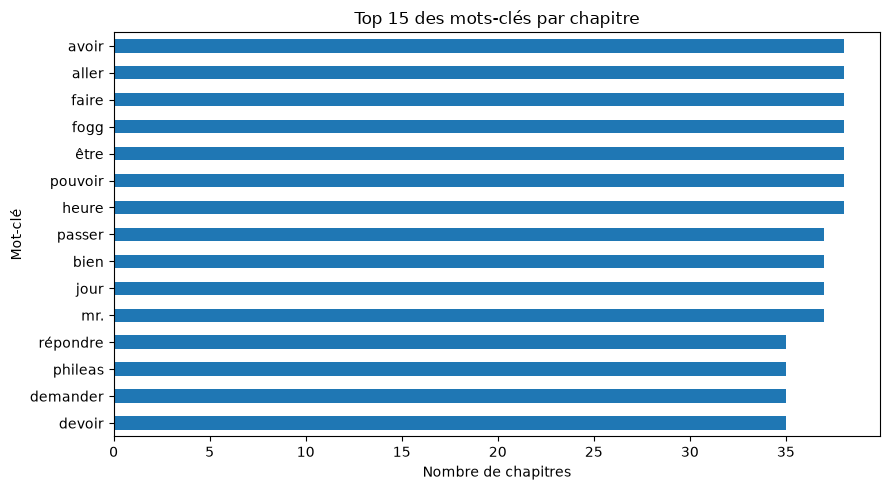

keywords
avoir       38
faire       38
aller       38
fogg        38
être        38
pouvoir     38
heure       38
mr.         37
jour        37
bien        37
passer      37
répondre    35
devoir      35
demander    35
phileas     35
Name: count, dtype: int64

In [135]:
plot_top_keywords_by_chapter(corpus_df_prep)

As we can see, there is still a lot of cleaning to do for example remove named entities etc.: this varies across use cases.  

## Appendix. Import

In [129]:
# all imports
'''
import pandas as pd
import httpx
from bs4 import BeautifulSoup
from IPython.display import display, HTML, Image, JSON
import xml.etree.ElementTree as ET
from xml.etree import ElementTree
from urllib.parse import quote
from tqdm.auto import tqdm
import lyricsgenius
import spacy
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
'''

'\nimport pandas as pd\nimport httpx\nfrom bs4 import BeautifulSoup\nfrom IPython.display import display, HTML, Image, JSON\nimport xml.etree.ElementTree as ET\nfrom xml.etree import ElementTree\nfrom urllib.parse import quote\nfrom tqdm.auto import tqdm\nimport lyricsgenius\nimport spacy\nfrom spacy.lang.fr.stop_words import STOP_WORDS as fr_stop\n'